# 📓 Practice 5. The 2D Discrete-time Kalman Filter

## 🎯 학습 목표

- Practice 4 (1D)를 2D 평면 운동으로 확장
- 가속도 입력이 있는 차량의 상태 추정
- CV (등속) vs CA (등가속) 모델 비교를 통해 모델 선택의 영향 이해

---

## 📦 노트북 구성

| 파트 | 내용 | 핵심 결과물 |
|------|------|-------------|
| **5-1-1** | 2D 차량 State Simulation (가속도 입력) | 참값 `x_history` (N, 4) |
| **5-1-2** | Measurement Simulation (X, Y 위치, 노이즈 포함) | 측정값 `y_history` (N, 2) |
| **5-2**   | CV (등속) 칼만필터 추정 + RMSE + P plot | CV 추정 결과 |
| **5-3-1** | CA 모델 F 행렬 유도 (이론) | F 행렬 (6×6) |
| **5-3-2~4** | CA (등가속) 칼만필터 추정 + RMSE + P plot | CA 추정 결과 |
| **5-3-5** | CV vs CA 성능 비교 분석 | 비교 plot + 서술 |

---

## 🔗 셀 간 의존 관계

```
5-1-1 (참값 생성)
   ↓
5-1-2 (측정값 생성) ← 5-1-1의 참값 사용
   ↓
   ├──→ 5-2 (CV 추정) ← 측정값 입력, 참값으로 RMSE 계산
   │
   └──→ 5-3-2~4 (CA 추정) ← 측정값 입력, 참값으로 RMSE 계산
              ↓
         5-3-5 (CV vs CA 비교) ← 5-2와 5-3 결과 모두 사용
```

> ⚠️ **셀을 순서대로 실행해야 함**
> 앞 셀의 변수(`x_history`, `y_history` 등)를 뒷 셀에서 재사용

---

## 📐 시스템 정보 요약

### Practice 5-1 (시뮬레이션 - 가속도 입력 모델)
- 상태: x_t = [x, y, v_x, v_y]ᵀ (4차원)
- 입력: a_t = [a_x, a_y]ᵀ (시간 구간별로 변함)
- 측정: y_t = [x, y]ᵀ (2차원, 노이즈 포함)

### Practice 5-2 (CV 모델 추정)
- 상태: x_t = [x, y, v_x, v_y]ᵀ (4차원)
- 가속도는 process noise로 처리 → 모델 불일치

### Practice 5-3 (CA 모델 추정)
- 상태: x_t = [x, y, v_x, v_y, a_x, a_y]ᵀ (6차원)
- 가속도까지 상태에 포함 → 모델 일치

---

## ⚙️ 공통 시뮬레이션 조건

- 샘플링 시간: dT = 0.1 s
- 시뮬레이션 구간: t = 0 ~ 30 s (총 301 step)
- 초기 위치: x_0 = 1 m, y_0 = 1 m
- 초기 속도: v_x = 0 m/s, v_y = 0 m/s
- 측정 노이즈 표준편차: σ = 1 m

### 가속도 입력 프로파일

```
         ┌  2 m/s²   (t < 10)
   a_x = │  4 m/s²   (10 ≤ t < 20)
         └  2 m/s²   (t ≥ 20)

         ┌  2 m/s²   (t < 10)
   a_y = │  4 m/s²   (10 ≤ t < 20)
         └  2 m/s²   (t ≥ 20)
```

---

## 💡 진행 방식

각 파트는 **markdown 셀(풀이 전략) + code 셀(구현)** 한 쌍으로 구성

1. 먼저 markdown 셀에서 풀이 절차를 확인
2. 다음 코드 셀에서 구현
3. 결과 확인 후 다음 파트로 이동

# 📋 Practice 5-1-1. State Simulation (2D Vehicle with Acceleration)

## ■ 목표
- 가속도 입력이 있는 2D 차량의 참값 상태 [x, y, v_x, v_y]를 시간에 따라 생성
- 이 결과는 5-1-2(측정값), 5-2/5-3(칼만필터 검증)의 ground truth로 사용

## ■ 시스템 모델 (가속도 입력 동역학)

운동방정식:
```
x_{t+1}   = x_t + v_x · dT + ½ · a_x · dT²
y_{t+1}   = y_t + v_y · dT + ½ · a_y · dT²
v_x_{t+1} = v_x_t + a_x · dT
v_y_{t+1} = v_y_t + a_y · dT
```

행렬 형태:  x_{t+1} = F · x_t + G · a_t

```
        ┌ 1  0  dT  0 ┐         ┌ ½dT²    0   ┐
        │ 0  1  0   dT│         │   0   ½dT²  │
   F =  │ 0  0  1   0 │    G =  │  dT     0   │
        └ 0  0  0   1 ┘         └   0    dT   ┘
```

## ■ 가속도 입력 (시간 구간별)

```
         ┌  2 m/s²   (t < 10)
   a_x = │  4 m/s²   (10 ≤ t < 20)
         └  2 m/s²   (t ≥ 20)

         ┌  2 m/s²   (t < 10)
   a_y = │  4 m/s²   (10 ≤ t < 20)
         └  2 m/s²   (t ≥ 20)
```

## ■ 조건
- dT = 0.1 s
- 시뮬레이션 구간: t = 0 ~ 30 s (총 N step)
- 초기 위치: x_0 = 1 m, y_0 = 1 m
- 초기 속도: v_x_0 = 0, v_y_0 = 0

## ■ 풀이 절차

### 1️⃣ 시뮬레이션 조건 설정
- dT, t_end, 시간 배열 t 생성

### 2️⃣ 시스템 행렬 정의
- F (4×4), G (4×2) 행렬 정의

### 3️⃣ 가속도 입력 배열 생성
- 시간 구간별로 a_x, a_y 값 다르게 설정

### 4️⃣ 초기 상태 + 저장 배열 준비
- x_0 = [1, 1, 0, 0]ᵀ
- x_history (N × 4) 배열 준비

### 5️⃣ 시간 루프 (State Propagation)
- 매 step마다 x_{k+1} = F · x_k + G · a_k 반복

### 6️⃣ 결과 시각화
- 각 상태(x, y, v_x, v_y)의 시간에 따른 plot
- 2D 평면에서의 차량 궤적 (x-y plot)

---

## ■ 한줄 정리

> 👉 "가속도 입력에 따라 등가속 운동하는 2D 차량의 진짜 상태(ground truth)를 생성"

---

## 💡 헷갈리기 쉬운 포인트

- **G의 dimension**: (4, 2). 가속도 입력 a_t는 (2, 1)이므로 G·a_t = (4, 1)
- **가속도 입력 처리**: 매 step마다 현재 시간 `t[k]`에 해당하는 a_x, a_y 값 선택
- **np.where 활용**: 시간 구간별로 가속도 값 부여할 때 편리
- **시간 구간 경계**: t < 10 (미만), 10 ≤ t < 20 (이상~미만)

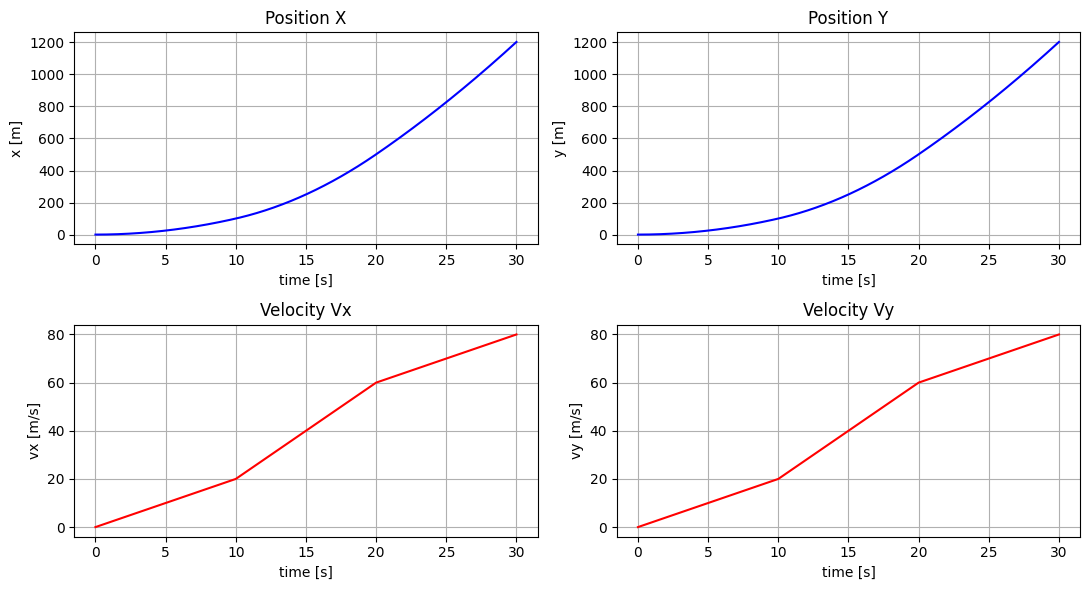

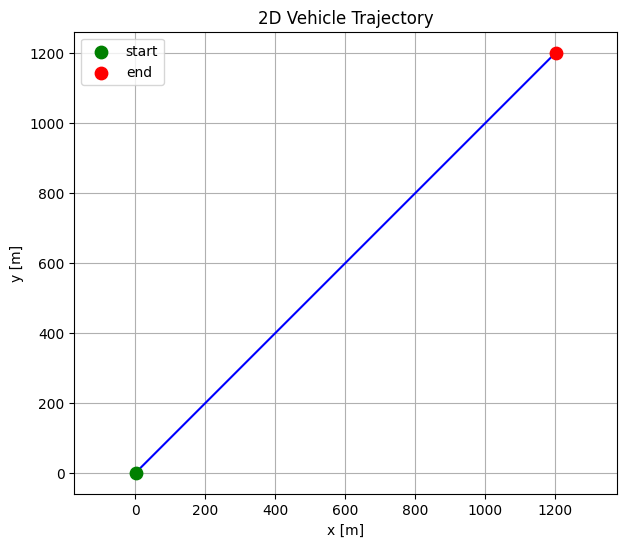

최종 위치: x = 1201.00 m,  y = 1201.00 m
최종 속도: vx = 80.00 m/s, vy = 80.00 m/s
x_history shape: (301, 4)


In [1]:
# =========================================
# 1️⃣ 라이브러리 불러오기
# =========================================
import numpy as np
import matplotlib.pyplot as plt


# =========================================
# 2️⃣ 시뮬레이션 조건 설정
# =========================================
dT     = 0.1                              # 샘플링 시간 [s]
t_end  = 30                               # 종료 시간 [s]
t      = np.arange(0, t_end + dT, dT)     # [0, 0.1, ..., 30] → (301,)
N      = len(t)                           # 시간 step 개수


# =========================================
# 3️⃣ 시스템 행렬 정의
#    상태: [x, y, vx, vy]^T (4차원)
#    입력: [ax, ay]^T (2차원)
#    
#    x_{t+1} = F @ x_t + G @ a_t
# =========================================
F = np.array([[1.0, 0.0, dT,  0.0],
              [0.0, 1.0, 0.0, dT ],
              [0.0, 0.0, 1.0, 0.0],
              [0.0, 0.0, 0.0, 1.0]])      # (4, 4)

G = np.array([[0.5*dT**2, 0.0      ],
              [0.0,       0.5*dT**2],
              [dT,        0.0      ],
              [0.0,       dT       ]])    # (4, 2)


# =========================================
# 4️⃣ 가속도 입력 배열 생성
#    시간 구간별로 다른 가속도 값 부여
# =========================================
a_x = np.zeros(N)                         # (N,) 가속도 x 배열
a_y = np.zeros(N)                         # (N,) 가속도 y 배열

for k in range(N):
    if t[k] < 10:
        a_x[k] = 2.0
        a_y[k] = 2.0
    elif t[k] < 20:                       # 10 ≤ t < 20
        a_x[k] = 4.0
        a_y[k] = 4.0
    else:                                 # t ≥ 20
        a_x[k] = 2.0
        a_y[k] = 2.0


# =========================================
# 5️⃣ 초기 상태 + 저장 배열 준비
#    초기 위치: (1, 1), 초기 속도: (0, 0)
# =========================================
x = np.array([[1.0],                      # x_0  : 1 m
              [1.0],                      # y_0  : 1 m
              [0.0],                      # vx_0 : 0 m/s
              [0.0]])                     # vy_0 : 0 m/s
                                          # (4, 1) 열벡터

x_history = np.zeros((N, 4))              # 각 step의 [x, y, vx, vy]
x_history[0] = x.flatten()                # 초기값 저장 (k=0)


# =========================================
# 6️⃣ State Propagation 루프
#    매 step:  x_{k+1} = F @ x_k + G @ a_k
# =========================================
for k in range(1, N):
    # 현재 시점의 가속도 입력 (2, 1) 열벡터로 만들기
    a = np.array([[a_x[k-1]],             # 직전 step의 가속도 사용
                  [a_y[k-1]]])            # (2, 1)
    
    # 상태 전파
    x = F @ x + G @ a                     # (4,1) = (4,4)@(4,1) + (4,2)@(2,1)
    
    # 저장
    x_history[k] = x.flatten()


# =========================================
# 7️⃣ 결과 시각화 ① - 각 상태별 시간 그래프
# =========================================
fig, axes = plt.subplots(2, 2, figsize=(11, 6))

# x 위치
axes[0, 0].plot(t, x_history[:, 0], 'b-')
axes[0, 0].set_title('Position X')
axes[0, 0].set_xlabel('time [s]'); axes[0, 0].set_ylabel('x [m]')
axes[0, 0].grid(True)

# y 위치
axes[0, 1].plot(t, x_history[:, 1], 'b-')
axes[0, 1].set_title('Position Y')
axes[0, 1].set_xlabel('time [s]'); axes[0, 1].set_ylabel('y [m]')
axes[0, 1].grid(True)

# vx 속도
axes[1, 0].plot(t, x_history[:, 2], 'r-')
axes[1, 0].set_title('Velocity Vx')
axes[1, 0].set_xlabel('time [s]'); axes[1, 0].set_ylabel('vx [m/s]')
axes[1, 0].grid(True)

# vy 속도
axes[1, 1].plot(t, x_history[:, 3], 'r-')
axes[1, 1].set_title('Velocity Vy')
axes[1, 1].set_xlabel('time [s]'); axes[1, 1].set_ylabel('vy [m/s]')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


# =========================================
# 8️⃣ 결과 시각화 ② - 2D 차량 궤적
# =========================================
plt.figure(figsize=(7, 6))
plt.plot(x_history[:, 0], x_history[:, 1], 'b-', linewidth=1.5)
plt.scatter(x_history[0, 0], x_history[0, 1],
            c='green', s=80, label='start', zorder=3)
plt.scatter(x_history[-1, 0], x_history[-1, 1],
            c='red',   s=80, label='end',   zorder=3)
plt.title('2D Vehicle Trajectory')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


# =========================================
# 9️⃣ 결과 확인 (선택)
# =========================================
print(f"최종 위치: x = {x_history[-1, 0]:.2f} m,  y = {x_history[-1, 1]:.2f} m")
print(f"최종 속도: vx = {x_history[-1, 2]:.2f} m/s, vy = {x_history[-1, 3]:.2f} m/s")
print(f"x_history shape: {x_history.shape}")

다음 단계 (5-1-2)에서 사용할 변수

- t (시간 배열)
- x_history[:, 0], x_history[:, 1] ← 진짜 위치 (측정값 만들 때 사용)
- x_history 전체 ← 5-2, 5-3의 RMSE 계산용 ground truth
- dT, N, F ← 그대로 재사용

# 📋 Practice 5-1-2. Measurement Simulation (2D Position Sensor)

## ■ 목표
- 5-1-1에서 만든 참 위치 (x_t, y_t)에 가우시안 노이즈를 더해 측정값 생성
- X, Y 두 개의 측정값을 동시에 생성

## ■ 측정 모델

```
y_{t+1} = H · x_{t+1} + r_t
```

```
        ┌ 1  0  0  0 ┐                 ┌ r_x ┐
   H =  │            │           r_t = │     │ ~ N(0, σ²·I)
        └ 0  1  0  0 ┘                 └ r_y ┘
```

> H = (2, 4) : 위치(x, y)만 측정 가능, 속도(vx, vy)는 측정 불가
> 센서 = 거리 센서가 원점에 위치 → 차량의 X, Y 위치 측정

## ■ 조건

- 측정 노이즈 표준편차: σ = 1 m
- X, Y 각각 **독립적인** 가우시안 노이즈 적용
- 측정 시점: 5-1-1과 동일한 시간 배열 t (0 ~ 30 s)

## ■ 풀이 절차

### 1️⃣ 측정 행렬 정의
- H = [[1, 0, 0, 0], [0, 1, 0, 0]] (2×4)

### 2️⃣ 노이즈 생성
- np.random.normal(0, σ, N) 으로 X, Y 각각 독립 생성
- 두 개의 1D 배열 → 합쳐서 (N, 2) 배열로

### 3️⃣ 측정값 계산
- 진짜 위치 + 노이즈
- y_x = x_history[:, 0] + r_x
- y_y = x_history[:, 1] + r_y

### 4️⃣ 결과 시각화
- 진짜 X 위치 vs 측정 X 위치 plot
- 진짜 Y 위치 vs 측정 Y 위치 plot
- 2D 평면에서 진짜 궤적 vs 측정 궤적 비교

---

## ■ 한줄 정리

> 👉 "5-1-1의 참 위치 (x, y)에 독립적인 가우시안 노이즈를 더해 2D 센서 측정값 생성"
> 👉 5-2 (CV), 5-3 (CA) 칼만필터의 입력 데이터로 사용됨

---

## 💡 헷갈리기 쉬운 포인트

- **노이즈는 X, Y 독립**: 같은 분포지만 서로 다른 난수 (별도로 normal 호출)
- **y_history shape**: (N, 2) → 2개 측정값을 시간별로 저장
- **속도는 측정 안 됨**: 칼만필터가 위치만으로 속도 추정해야 함
- **np.random.seed**: 재현성을 위해 seed 고정 권장

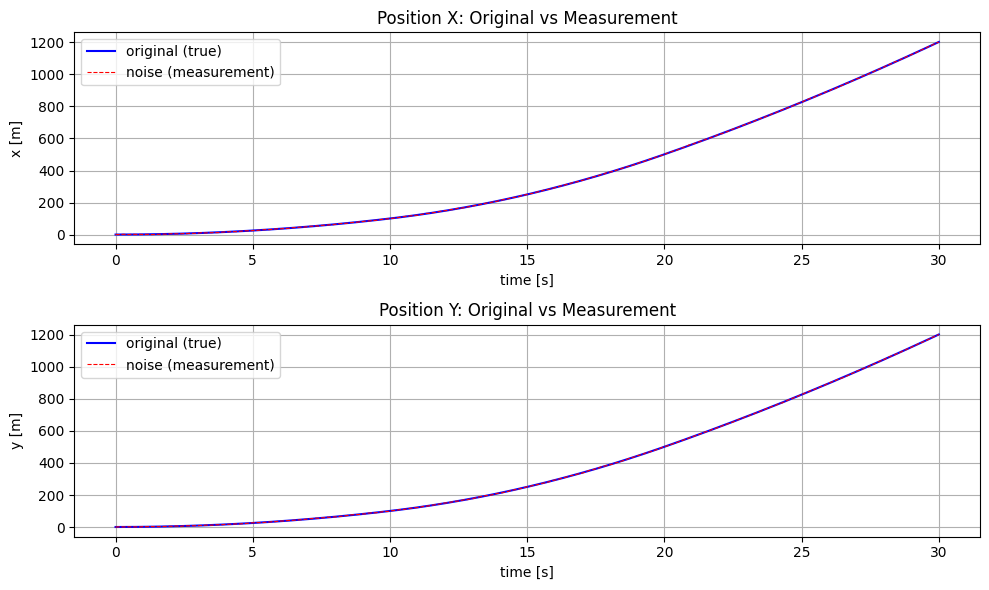

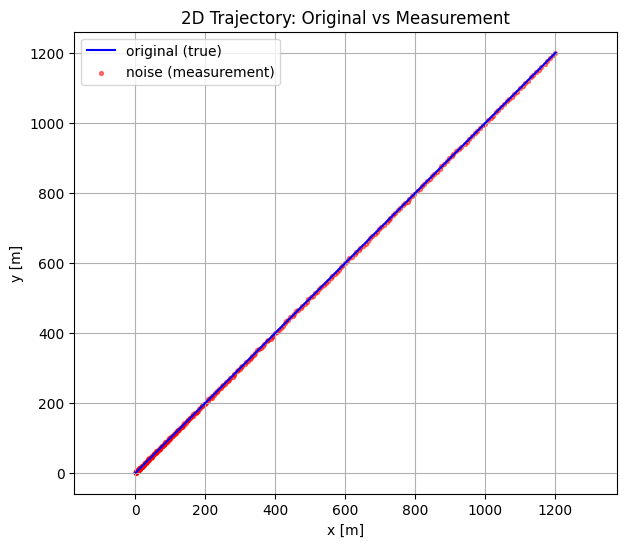

r_x 평균   : -0.0083 (이론: 0)
r_x 표준편차: 0.9821  (이론: 1.0)
r_y 평균   : -0.0192 (이론: 0)
r_y 표준편차: 0.9597  (이론: 1.0)
y_history shape: (301, 2)


In [2]:
# =========================================
# 1️⃣ 노이즈 재현성을 위한 seed 설정
#    매번 같은 결과를 보고 싶으면 사용
# =========================================
np.random.seed(42)


# =========================================
# 2️⃣ 측정 모델 정의
#    y_t = H @ x_t + r_t
#    H = (2, 4) → 위치 x, y만 측정
# =========================================
H = np.array([[1.0, 0.0, 0.0, 0.0],       # x 위치 추출
              [0.0, 1.0, 0.0, 0.0]])      # y 위치 추출
                                          # (2, 4) 행렬


# =========================================
# 3️⃣ 측정 노이즈 생성
#    X, Y 각각 독립적으로 N(0, σ²) 생성
# =========================================
sigma = 1.0                               # 표준편차 1 m

r_x = np.random.normal(0, sigma, N)       # (N,) X 노이즈
r_y = np.random.normal(0, sigma, N)       # (N,) Y 노이즈


# =========================================
# 4️⃣ 측정값 생성
#    진짜 위치 + 노이즈
#    x_history[:, 0] = 모든 시간의 진짜 X 위치
#    x_history[:, 1] = 모든 시간의 진짜 Y 위치
# =========================================
y_history = np.zeros((N, 2))              # (N, 2) 측정값 배열

y_history[:, 0] = x_history[:, 0] + r_x   # 측정 X = 진짜 X + 노이즈
y_history[:, 1] = x_history[:, 1] + r_y   # 측정 Y = 진짜 Y + 노이즈


# =========================================
# 5️⃣ 결과 시각화 ① - 시간에 따른 X, Y 비교
# =========================================
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# X 위치 비교
axes[0].plot(t, x_history[:, 0],  'b-',  label='original (true)', linewidth=1.5)
axes[0].plot(t, y_history[:, 0],  'r--', label='noise (measurement)', linewidth=0.8)
axes[0].set_title('Position X: Original vs Measurement')
axes[0].set_xlabel('time [s]'); axes[0].set_ylabel('x [m]')
axes[0].legend(); axes[0].grid(True)

# Y 위치 비교
axes[1].plot(t, x_history[:, 1],  'b-',  label='original (true)', linewidth=1.5)
axes[1].plot(t, y_history[:, 1],  'r--', label='noise (measurement)', linewidth=0.8)
axes[1].set_title('Position Y: Original vs Measurement')
axes[1].set_xlabel('time [s]'); axes[1].set_ylabel('y [m]')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


# =========================================
# 6️⃣ 결과 시각화 ② - 2D 평면 궤적 비교
# =========================================
plt.figure(figsize=(7, 6))
plt.plot(x_history[:, 0], x_history[:, 1],
         'b-',  linewidth=1.5, label='original (true)')
plt.scatter(y_history[:, 0], y_history[:, 1],
            c='red', s=8, alpha=0.5, label='noise (measurement)')

plt.title('2D Trajectory: Original vs Measurement')
plt.xlabel('x [m]'); plt.ylabel('y [m]')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


# =========================================
# 7️⃣ 노이즈 통계 확인 (검증용)
# =========================================
print(f"r_x 평균   : {np.mean(r_x):.4f} (이론: 0)")
print(f"r_x 표준편차: {np.std(r_x):.4f}  (이론: {sigma})")
print(f"r_y 평균   : {np.mean(r_y):.4f} (이론: 0)")
print(f"r_y 표준편차: {np.std(r_y):.4f}  (이론: {sigma})")
print(f"y_history shape: {y_history.shape}")

📌 다음 단계 (5-2)에서 사용할 변수

- y_history ← CV 칼만필터의 측정값 입력
- x_history ← RMSE 계산용 ground truth
- t, dT, N, F, H ← 그대로 재사용
- sigma ← R 행렬 만들 때 사용 (R = σ²·I)

- 이 변수들이 5-2, 5-3에서 모두 재사용되니까 셀 순서대로 실행 필수예요!

# 📋 Practice 5-2. Kalman Filter with CV (Constant Velocity) Model

## ■ 목표
- 5-1에서 만든 측정값 (x, y)으로 차량의 상태 [x, y, v_x, v_y] 추정
- **모델 불일치 상황 실험**: 시뮬레이션은 가속도 있음 / 추정 모델은 가속도 무시(CV)
- 가속도 정보가 없는 상태에서 CV 모델로 얼마나 잘 추정되는지 확인

## ■ CV Process Model

```
x_{t+1} = F · x_t + w_t,    w_t ~ N(0, Q)
```

```
        ┌ 1  0  dT  0 ┐
        │ 0  1  0   dT│
   F =  │ 0  0  1   0 │
        └ 0  0  0   1 ┘
```

> 가속도가 모델에 없음 → process noise w_t로 보상

## ■ Measurement Model

```
y_t = H · x_t + r_t,    r_t ~ N(0, R)
```

```
        ┌ 1  0  0  0 ┐                     ┌ σ²   0  ┐
   H =  │            │                R =  │         │
        └ 0  1  0  0 ┘                     └  0   σ² ┘
```

## ■ Q 행렬 설계 (가속도 불확실성 기반)

CV 모델에서 빠진 가속도를 process noise로 처리하면 Q는 다음과 같이 유도됨:

```
Q  =  E[w · wᵀ]  =  G · Q_v · Gᵀ
```

여기서 G는 가속도→상태 변환 행렬, Q_v = diag(σ_ax², σ_ay²)

```
       ┌ dT⁴/4·σ_ax²        0          dT³/2·σ_ax²       0       ┐
       │      0         dT⁴/4·σ_ay²        0         dT³/2·σ_ay² │
  Q =  │ dT³/2·σ_ax²        0          dT²·σ_ax²         0       │
       └      0         dT³/2·σ_ay²        0          dT²·σ_ay²  ┘
```

> **튜닝 변수**: σ_ax, σ_ay (가속도 불확실성 표준편차)
> 실제 가속도가 2~4 m/s² 변하므로 σ ≈ 1~2 정도가 적절

## ■ 초기 조건

- 초기 상태: x_0 = [0, 0, 0, 0]ᵀ (위치, 속도 모두 0으로 시작)
- 초기 공분산: P_0 = diag(10000, 10000, 10000, 10000) (불확실성 매우 큼)

## ■ 풀이 절차

### 1️⃣ CV 모델용 행렬 정의
- F (4×4), H (2×4) 정의

### 2️⃣ Q, R, 초기값 설정
- σ_ax, σ_ay 튜닝 → Q 계산
- σ_meas (측정 노이즈) 기반으로 R 계산
- x_0, P_0 설정

### 3️⃣ 칼만필터 루프
- Prediction: x̂⁻ = F·x̂, P⁻ = F·P·Fᵀ + Q
- Update: K = P⁻Hᵀ(HP⁻Hᵀ+R)⁻¹, x̂⁺ = x̂⁻ + K(y−Hx̂⁻), P⁺ = (I−KH)P⁻

### 4️⃣ 결과 시각화 (5-2-1)
- 추정 상태 plot (x, y, v_x, v_y)
- 추정 오차 plot

### 5️⃣ RMSE 계산 (5-2-2)
- 4개 상태 각각의 RMSE

### 6️⃣ 공분산 P plot (5-2-3)
- P_00 ~ P_33 (4×4 = 16개 원소)의 시간 변화

---

## ■ 한줄 정리

> 👉 "가속도 정보를 모르는 채로 CV 모델로 칼만필터 돌려서, 가속도 변화 구간에서 어떤 일이 벌어지는지 관찰"

---

## 💡 헷갈리기 쉬운 포인트

- **Q 행렬의 σ_ax 튜닝**: 너무 작으면 추적 못 따라감, 너무 크면 노이즈에 민감
- **R 행렬**: 측정 노이즈는 X, Y 독립 → R = diag(σ², σ²)
- **측정값 차원**: y_t는 (2, 1) 열벡터로 만들어야 행렬 연산 깔끔
- **innovation 차원**: y - H·x̂ → (2, 1)
- **K 차원**: (4, 2)

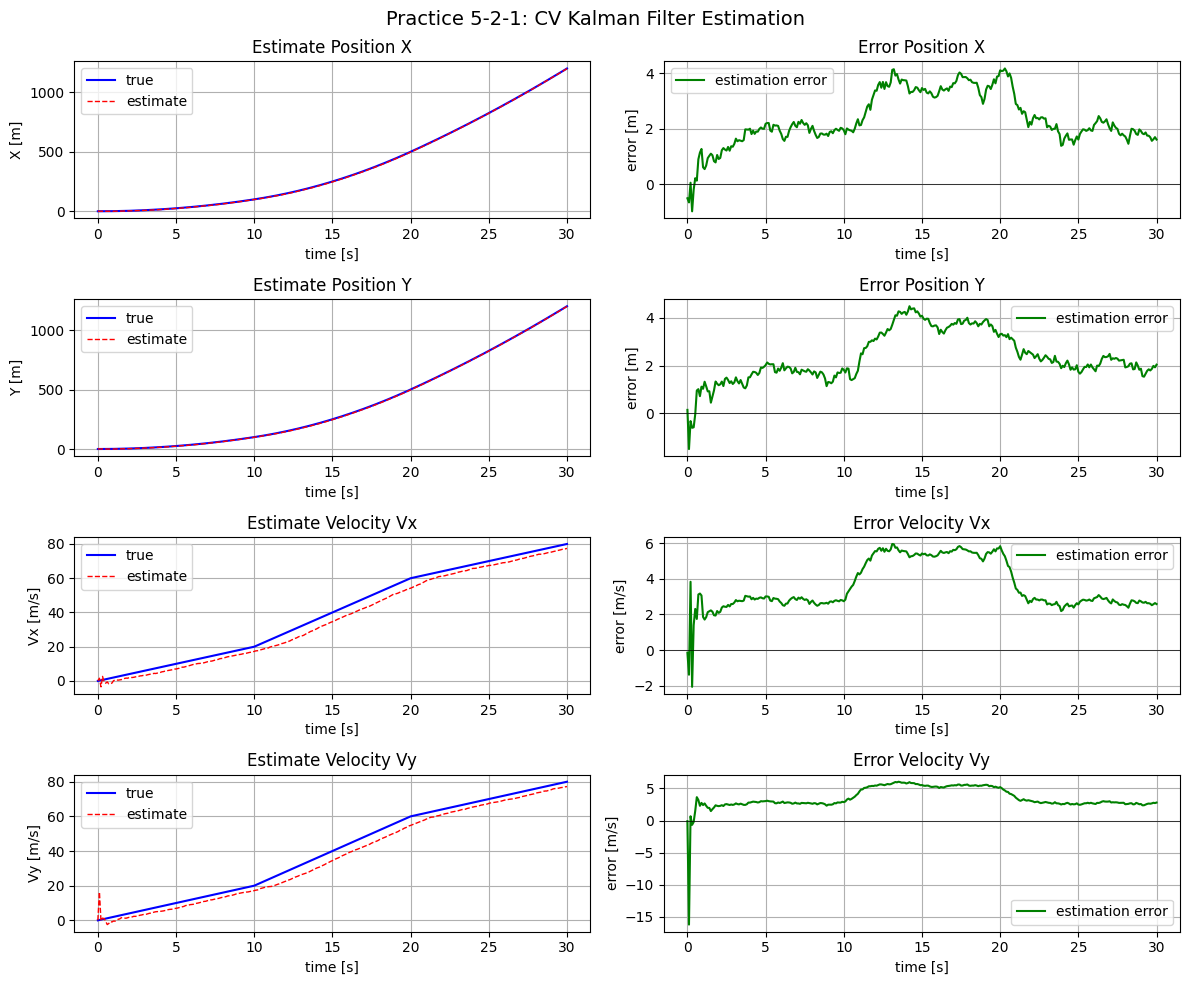

Practice 5-2-2: CV Kalman Filter RMSE
RMSE x  : 2.5487 m
RMSE y  : 2.5828 m
RMSE vx : 3.8305 m/s
RMSE vy : 3.9398 m/s


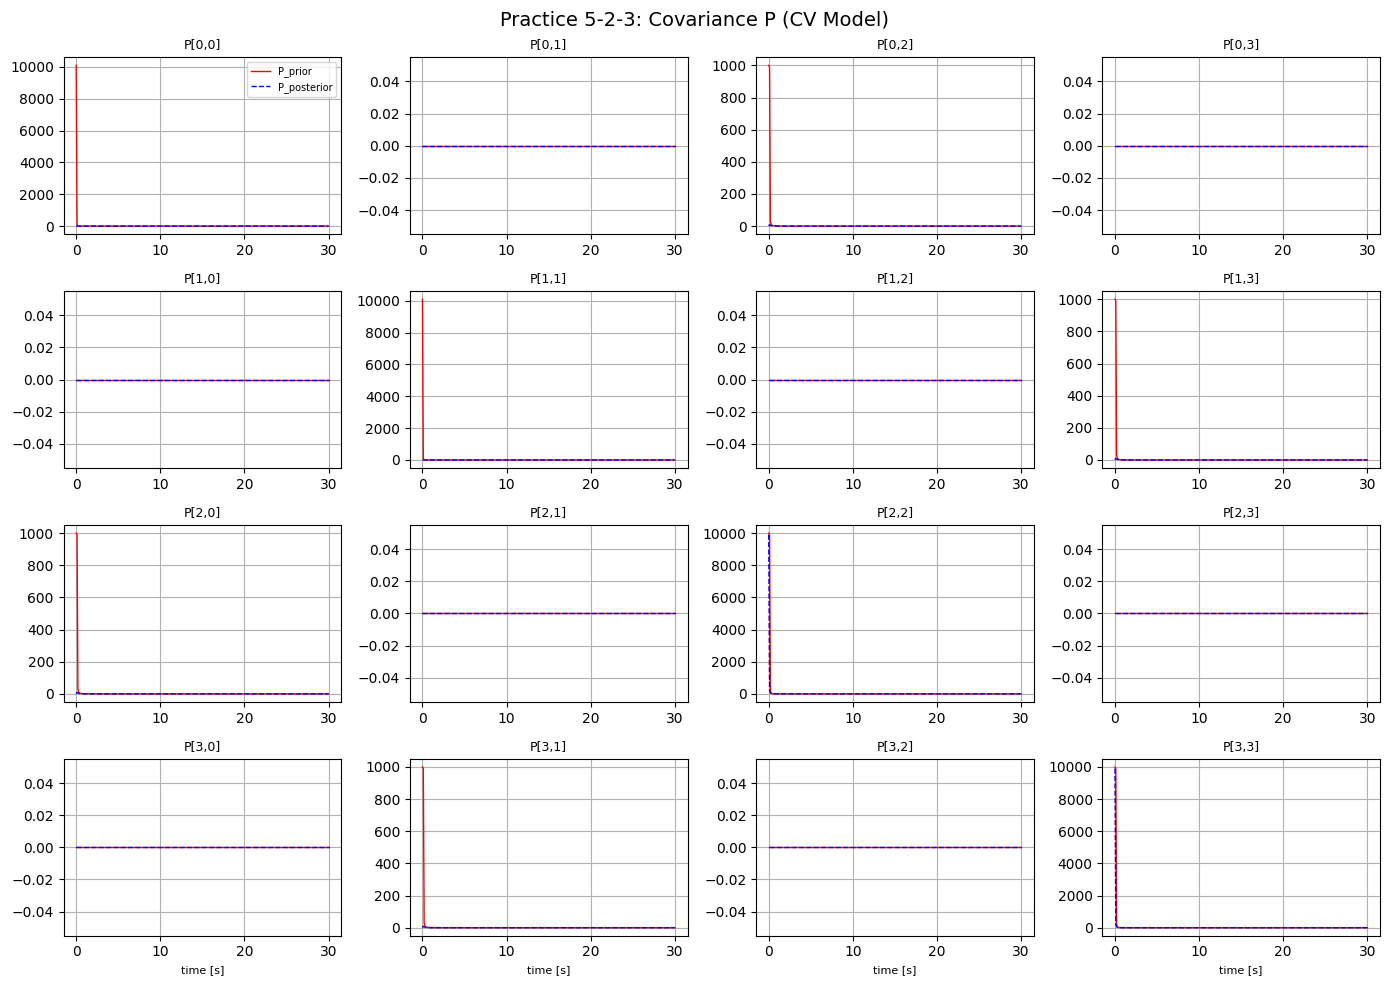

In [9]:
# =========================================
# 1️⃣ CV 모델용 행렬 정의
# =========================================
F_cv = np.array([[1.0, 0.0, dT,  0.0],
                 [0.0, 1.0, 0.0, dT ],
                 [0.0, 0.0, 1.0, 0.0],
                 [0.0, 0.0, 0.0, 1.0]])  # (4, 4)

H_cv = np.array([[1.0, 0.0, 0.0, 0.0],
                 [0.0, 1.0, 0.0, 0.0]])  # (2, 4)


# =========================================
# 2️⃣ Q 행렬 설계 (가속도 불확실성 기반)
#    σ_ax, σ_ay : 튜닝 변수
#    Q = G @ Q_v @ G.T 의 결과를 직접 입력
# =========================================
sigma_ax = 1.0                            # 가속도 X 불확실성 [m/s²]
sigma_ay = 1.0                            # 가속도 Y 불확실성 [m/s²]

Q_cv = np.array([
    [dT**4/4 * sigma_ax**2,  0.0,                    dT**3/2 * sigma_ax**2, 0.0                  ],
    [0.0,                    dT**4/4 * sigma_ay**2,  0.0,                   dT**3/2 * sigma_ay**2],
    [dT**3/2 * sigma_ax**2,  0.0,                    dT**2   * sigma_ax**2, 0.0                  ],
    [0.0,                    dT**3/2 * sigma_ay**2,  0.0,                   dT**2   * sigma_ay**2]
])
                                          # (4, 4) process noise 공분산


# =========================================
# 3️⃣ R 행렬 설정 (측정 노이즈 공분산)
#    측정 노이즈 σ = 1 m, X와 Y 독립
# =========================================
R_cv = np.array([[sigma**2, 0.0     ],
                 [0.0,      sigma**2]])  # (2, 2)


# =========================================
# 4️⃣ 초기 조건 설정
# =========================================
x_hat = np.array([[0.0],                  # 초기 추정 상태 [x, y, vx, vy]
                  [0.0],
                  [0.0],
                  [0.0]])                 # (4, 1)

P = np.diag([10000.0, 10000.0,
             10000.0, 10000.0])           # (4, 4) 초기 공분산 (큼)

I = np.eye(4)                             # 4×4 단위행렬


# =========================================
# 5️⃣ 저장 배열 준비
#    추정 상태 + 사전/사후 공분산 모두 저장
# =========================================
x_hat_cv      = np.zeros((N, 4))          # 추정 상태
P_prior_cv    = np.zeros((N, 4, 4))       # 사전 공분산
P_post_cv     = np.zeros((N, 4, 4))       # 사후 공분산


# =========================================
# 6️⃣ 칼만필터 루프
#    매 step:
#      Prediction  → x̂⁻, P⁻
#      Update      → x̂⁺, P⁺
# =========================================
for k in range(N):
    # ---------- Prediction ----------
    x_hat = F_cv @ x_hat                  # (4,1) = (4,4) @ (4,1)
    P     = F_cv @ P @ F_cv.T + Q_cv      # (4,4)
    P_prior_cv[k] = P                     # 사전 공분산 저장
    
    # ---------- Update ----------
    # 측정값을 (2,1) 열벡터로
    y_k = y_history[k].reshape(2, 1)      # (2, 1)
    
    # Innovation covariance
    S = H_cv @ P @ H_cv.T + R_cv          # (2, 2)
    
    # Kalman gain
    K = P @ H_cv.T @ np.linalg.inv(S)     # (4, 2)
    
    # Innovation (잔차)
    innovation = y_k - H_cv @ x_hat       # (2, 1) = (2, 1) − (2, 4) @ (4, 1)
    
    # 상태 보정
    x_hat = x_hat + K @ innovation        # (4, 1)
    
    # 공분산 보정
    P = (I - K @ H_cv) @ P                # (4, 4)
    P_post_cv[k] = P                      # 사후 공분산 저장
    
    # 결과 저장
    x_hat_cv[k] = x_hat.flatten()


# =========================================
# 7️⃣ Practice 5-2-1: 추정 상태 + 오차 plot
# =========================================
fig, axes = plt.subplots(4, 2, figsize=(12, 10))
labels = ['Position X', 'Position Y', 'Velocity Vx', 'Velocity Vy']
units  = ['m', 'm', 'm/s', 'm/s']

for i in range(4):
    # 좌측: 추정값 vs 참값
    axes[i, 0].plot(t, x_history[:, i],  'b-',  label='true', linewidth=1.5)
    axes[i, 0].plot(t, x_hat_cv[:, i],   'r--', label='estimate', linewidth=1.0)
    axes[i, 0].set_title(f'Estimate {labels[i]}')
    axes[i, 0].set_xlabel('time [s]')
    axes[i, 0].set_ylabel(f'{labels[i].split()[1]} [{units[i]}]')
    axes[i, 0].legend(); axes[i, 0].grid(True)
    
    # 우측: 오차 (true - estimate)
    error = x_history[:, i] - x_hat_cv[:, i]
    axes[i, 1].plot(t, error, 'g-', label='estimation error')
    axes[i, 1].axhline(0, color='k', linewidth=0.5)
    axes[i, 1].set_title(f'Error {labels[i]}')
    axes[i, 1].set_xlabel('time [s]')
    axes[i, 1].set_ylabel(f'error [{units[i]}]')
    axes[i, 1].legend(); axes[i, 1].grid(True)

plt.suptitle('Practice 5-2-1: CV Kalman Filter Estimation', fontsize=14)
plt.tight_layout()
plt.show()


# =========================================
# 8️⃣ Practice 5-2-2: RMSE 계산
# =========================================
rmse_x  = np.sqrt(np.mean((x_history[:, 0] - x_hat_cv[:, 0])**2))
rmse_y  = np.sqrt(np.mean((x_history[:, 1] - x_hat_cv[:, 1])**2))
rmse_vx = np.sqrt(np.mean((x_history[:, 2] - x_hat_cv[:, 2])**2))
rmse_vy = np.sqrt(np.mean((x_history[:, 3] - x_hat_cv[:, 3])**2))

print("=" * 50)
print("Practice 5-2-2: CV Kalman Filter RMSE")
print("=" * 50)
print(f"RMSE x  : {rmse_x:.4f} m")
print(f"RMSE y  : {rmse_y:.4f} m")
print(f"RMSE vx : {rmse_vx:.4f} m/s")
print(f"RMSE vy : {rmse_vy:.4f} m/s")
print("=" * 50)


# =========================================
# 9️⃣ Practice 5-2-3: 공분산 P plot
#    P 행렬 4×4 = 16개 원소, 사전/사후 모두 plot
# =========================================
fig, axes = plt.subplots(4, 4, figsize=(14, 10))

for i in range(4):
    for j in range(4):
        axes[i, j].plot(t, P_prior_cv[:, i, j], 'r-',  label='P_prior',     linewidth=1.0)
        axes[i, j].plot(t, P_post_cv[:, i, j],  'b--', label='P_posterior', linewidth=1.0)
        axes[i, j].set_title(f'P[{i},{j}]', fontsize=9)
        axes[i, j].grid(True)
        if i == 3:
            axes[i, j].set_xlabel('time [s]', fontsize=8)
        if i == 0 and j == 0:
            axes[i, j].legend(fontsize=7)

plt.suptitle('Practice 5-2-3: Covariance P (CV Model)', fontsize=14)
plt.tight_layout()
plt.show()

📌 다음 단계 (5-3)에서 사용할 변수

- x_hat_cv, P_prior_cv, P_post_cv ← 5-3-5 비교 분석용
- rmse_x, rmse_y, rmse_vx, rmse_vy ← CV 성능 기록

# ㅎㅎ



내가 짬 ! sigma_ax와 sigma_ay를 2D sweep해서 RMSE 3D surface plot + 최적 조합 찾는 코드 짜줄게.

Q 튜닝 sweep 시작...
  σ_ax, σ_ay: 96 × 96 = 9216 조합 탐색
  탐색 범위: 1.0 ~ 20.0
  탐색 간격: 0.2
  [10/96] σ_ax = 2.80 완료
  [20/96] σ_ax = 4.80 완료
  [30/96] σ_ax = 6.80 완료
  [40/96] σ_ax = 8.80 완료
  [50/96] σ_ax = 10.80 완료
  [60/96] σ_ax = 12.80 완료
  [70/96] σ_ax = 14.80 완료
  [80/96] σ_ax = 16.80 완료
  [90/96] σ_ax = 18.80 완료
Sweep 완료!

최적 σ 조합 탐색 결과
  최적 σ_ax  = 10.2000
  최적 σ_ay  = 10.4000
  최소 RMSE  = 0.551828 m

최악 σ 조합 탐색 결과
  최악 σ_ax  = 1.0000
  최악 σ_ay  = 1.0000
  최대 RMSE  = 2.565788 m
 최적 조합으로 상세 RMSE 재계산  
  RMSE x  = 0.5476 m
  RMSE y  = 0.5561 m
  RMSE vx = 1.5578 m/s
  RMSE vy = 1.7785 m/s


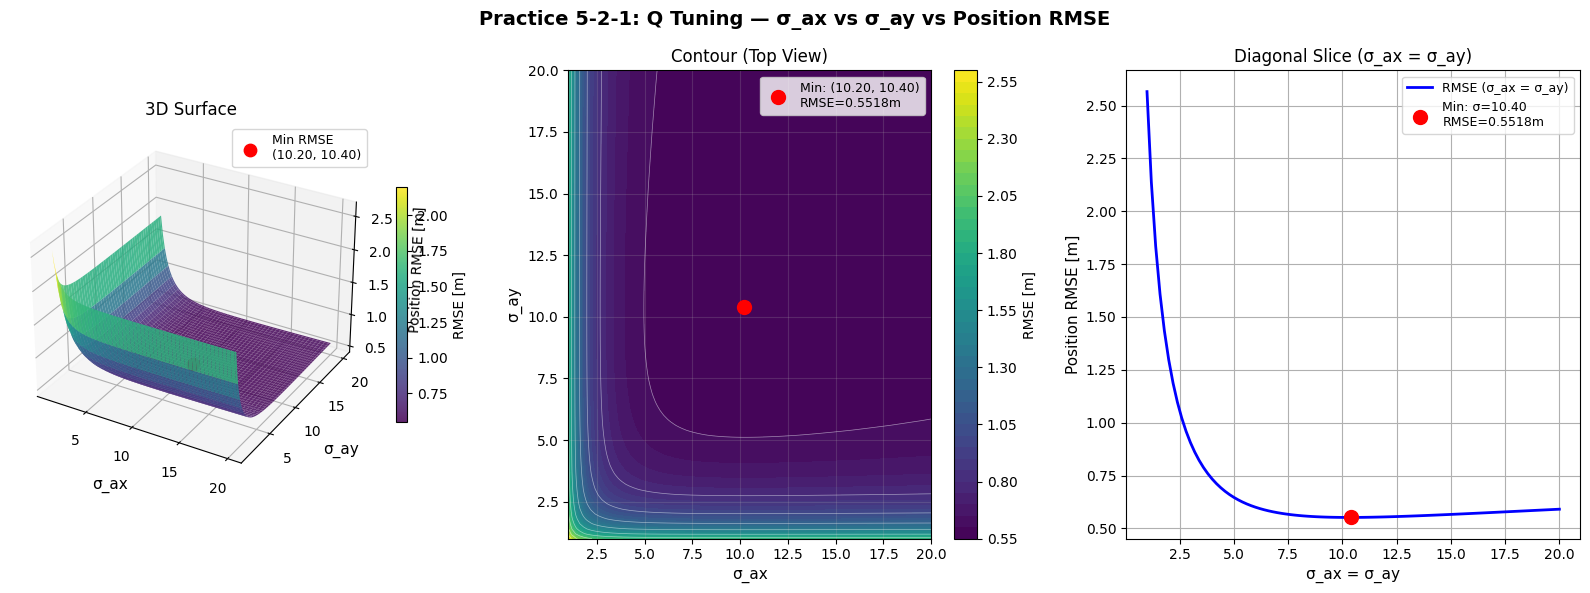


그래프 저장 완료: /home/harry/Ai_lab/git/Optimal-State-Estimate-Practice/outputs/Q_tuning_result.png


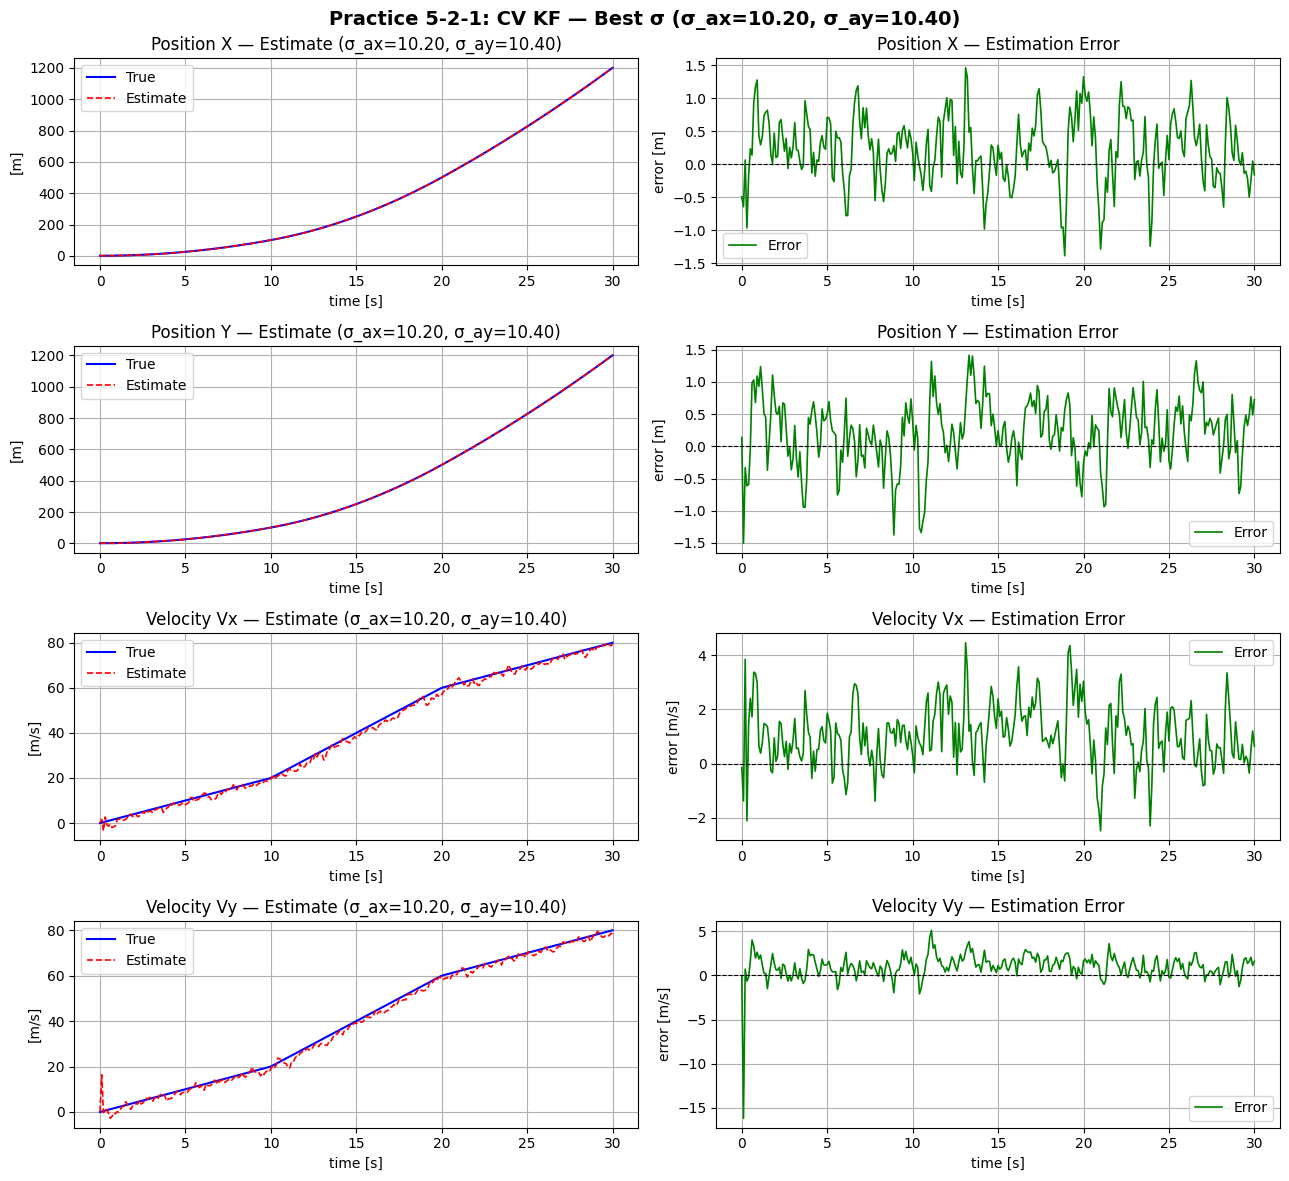

추정 결과 그래프 저장 완료: /home/harry/Ai_lab/git/Optimal-State-Estimate-Practice/outputs/KF_best_result.png


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import os

# =========================================
# 저장 경로 설정
# 현재 작업 폴더:
# /home/harry/Ai_lab/git/Optimal-State-Estimate-Practice
# =========================================
save_dir = "/home/harry/Ai_lab/git/Optimal-State-Estimate-Practice/outputs"
os.makedirs(save_dir, exist_ok=True)

# =========================================
# 공통 파라미터
# =========================================
dT     = 0.1
t_end  = 30.0
t      = np.arange(0, t_end + dT, dT)
N      = len(t)
sigma  = 1.0          # 측정 노이즈 표준편차

# =========================================
# Practice 1-1: True State 시뮬레이션
#   x_k = F_true x_{k-1} + G_true u_{k-1}
#   process noise = 0
# =========================================
F_true = np.array([[1.0, 0.0, dT,  0.0],
                   [0.0, 1.0, 0.0, dT ],
                   [0.0, 0.0, 1.0, 0.0],
                   [0.0, 0.0, 0.0, 1.0]])

G_true = np.array([[dT**2 / 2, 0.0       ],
                   [0.0,        dT**2 / 2],
                   [dT,         0.0       ],
                   [0.0,        dT        ]])

H = np.array([[1.0, 0.0, 0.0, 0.0],
              [0.0, 1.0, 0.0, 0.0]])   # 위치 x, y만 측정

# =========================================
# 구간별 가속도 입력
# =========================================
def get_acceleration(time):
    if time < 10.0:
        return np.array([2.0, 2.0])
    elif time < 20.0:
        return np.array([4.0, 4.0])
    else:
        return np.array([2.0, 2.0])

# =========================================
# True state 생성
# 상태: [x, y, vx, vy]^T
# =========================================
x0 = np.array([[1.0],
               [1.0],
               [0.0],
               [0.0]])

x_true = np.zeros((N, 4))
x_curr = x0.copy()

for k in range(N):
    x_true[k] = x_curr.flatten()

    a = get_acceleration(t[k])
    u = a.reshape(2, 1)

    x_curr = F_true @ x_curr + G_true @ u

# =========================================
# Practice 1-2: 측정값 생성
#   y_k = H x_k + v_k
#   v_k ~ N(0, R)
# =========================================
np.random.seed(42)

y_history = np.zeros((N, 2))

for k in range(N):
    noise = np.random.normal(0, sigma, size=2)
    y_history[k] = H @ x_true[k] + noise

# =========================================
# Measurement noise covariance R
# =========================================
R = np.array([[sigma**2, 0.0     ],
              [0.0,      sigma**2]])

# =========================================
# Kalman Filter 함수
#   입력:
#       sigma_ax, sigma_ay
#   출력:
#       rmse_pos : position 대표 RMSE
#       rmse     : [x, y, vx, vy] 각각의 RMSE
# =========================================
def run_kf_cv(sigma_ax, sigma_ay):
    # -----------------------------------------
    # Process noise covariance Q
    # Q = G Qv G^T
    # Qv = diag(sigma_ax^2, sigma_ay^2)
    # -----------------------------------------
    Q = np.array([
        [dT**4 / 4 * sigma_ax**2,  0.0,                         dT**3 / 2 * sigma_ax**2, 0.0                        ],
        [0.0,                         dT**4 / 4 * sigma_ay**2,   0.0,                        dT**3 / 2 * sigma_ay**2 ],
        [dT**3 / 2 * sigma_ax**2,  0.0,                         dT**2     * sigma_ax**2, 0.0                        ],
        [0.0,                         dT**3 / 2 * sigma_ay**2,   0.0,                        dT**2     * sigma_ay**2 ]
    ])

    # -----------------------------------------
    # CV model
    # 상태: [x, y, vx, vy]^T
    # -----------------------------------------
    F = np.array([[1.0, 0.0, dT,  0.0],
                  [0.0, 1.0, 0.0, dT ],
                  [0.0, 0.0, 1.0, 0.0],
                  [0.0, 0.0, 0.0, 1.0]])

    I4    = np.eye(4)
    x_hat = np.zeros((4, 1))          # 초기 추정값 [0, 0, 0, 0]^T
    P     = np.diag([10000.0] * 4)    # 초기 공분산

    x_hat_log = np.zeros((N, 4))

    for k in range(N):
        # =====================================
        # 1) Prediction
        # =====================================
        x_hat = F @ x_hat
        P     = F @ P @ F.T + Q

        # =====================================
        # 2) Measurement Update
        # =====================================
        y_k        = y_history[k].reshape(2, 1)
        S          = H @ P @ H.T + R
        K          = P @ H.T @ np.linalg.inv(S)
        innovation = y_k - H @ x_hat

        x_hat = x_hat + K @ innovation
        P     = (I4 - K @ H) @ P

        x_hat_log[k] = x_hat.flatten()

    # =========================================
    # RMSE 계산
    # =========================================
    rmse = np.sqrt(np.mean((x_true - x_hat_log)**2, axis=0))

    # 위치 x, y RMSE를 하나의 대표값으로 사용
    rmse_pos = np.sqrt(np.mean(rmse[:2]**2))

    return rmse_pos, rmse

# =========================================
# Sigma grid search
#   sigma_ax, sigma_ay를 0.2 단위로 탐색
# =========================================
sigma_vals = np.arange(1.0, 20.0 + 0.2, 0.2)
n_pts      = len(sigma_vals)

sigma_AX, sigma_AY = np.meshgrid(sigma_vals, sigma_vals)
RMSE_grid = np.zeros((n_pts, n_pts))

print("Q 튜닝 sweep 시작...")
print(f"  σ_ax, σ_ay: {n_pts} × {n_pts} = {n_pts**2} 조합 탐색")
print(f"  탐색 범위: {sigma_vals[0]:.1f} ~ {sigma_vals[-1]:.1f}")
print("  탐색 간격: 0.2")

for i, sax in enumerate(sigma_vals):
    for j, say in enumerate(sigma_vals):
        rmse_pos, _ = run_kf_cv(sax, say)
        RMSE_grid[j, i] = rmse_pos

    if (i + 1) % 10 == 0:
        print(f"  [{i+1}/{n_pts}] σ_ax = {sax:.2f} 완료")

print("Sweep 완료!")

# =========================================
# 최적 / 최악 조합 탐색
# =========================================

# ---- 최적 조합: RMSE 최소 ----
min_idx   = np.unravel_index(np.argmin(RMSE_grid), RMSE_grid.shape)
best_say  = sigma_vals[min_idx[0]]
best_sax  = sigma_vals[min_idx[1]]
best_rmse = RMSE_grid[min_idx]

# ---- 최악 조합: RMSE 최대 ----
max_idx    = np.unravel_index(np.argmax(RMSE_grid), RMSE_grid.shape)
worst_say  = sigma_vals[max_idx[0]]
worst_sax  = sigma_vals[max_idx[1]]
worst_rmse = RMSE_grid[max_idx]

print("\n" + "=" * 50)
print("최적 σ 조합 탐색 결과")
print("=" * 50)
print(f"  최적 σ_ax  = {best_sax:.4f}")
print(f"  최적 σ_ay  = {best_say:.4f}")
print(f"  최소 RMSE  = {best_rmse:.6f} m")
print("=" * 50)

print("\n" + "=" * 50)
print("최악 σ 조합 탐색 결과")
print("=" * 50)
print(f"  최악 σ_ax  = {worst_sax:.4f}")
print(f"  최악 σ_ay  = {worst_say:.4f}")
print(f"  최대 RMSE  = {worst_rmse:.6f} m")
print("=" * 50)

# 최적 조합으로 상세 RMSE 재계산
_, best_rmse_detail = run_kf_cv(best_sax, best_say)
print(" 최적 조합으로 상세 RMSE 재계산  ")
print(f"  RMSE x  = {best_rmse_detail[0]:.4f} m")
print(f"  RMSE y  = {best_rmse_detail[1]:.4f} m")
print(f"  RMSE vx = {best_rmse_detail[2]:.4f} m/s")
print(f"  RMSE vy = {best_rmse_detail[3]:.4f} m/s")

# =========================================
# 3D Surface Plot
# =========================================
fig = plt.figure(figsize=(16, 6))

fig.suptitle("Practice 5-2-1: Q Tuning — σ_ax vs σ_ay vs Position RMSE",
             fontsize=14,
             fontweight="bold")

# -----------------------------------------
# (1) 3D Surface
# -----------------------------------------
ax1 = fig.add_subplot(131, projection="3d")

surf = ax1.plot_surface(sigma_AX,
                        sigma_AY,
                        RMSE_grid,
                        cmap=cm.viridis,
                        alpha=0.85,
                        linewidth=0)

ax1.scatter([best_sax],
            [best_say],
            [best_rmse],
            color="red",
            s=80,
            zorder=5,
            label=f"Min RMSE\n({best_sax:.2f}, {best_say:.2f})")

ax1.set_xlabel("σ_ax", fontsize=11, labelpad=8)
ax1.set_ylabel("σ_ay", fontsize=11, labelpad=8)
ax1.set_zlabel("Position RMSE [m]", fontsize=10, labelpad=8)
ax1.set_title("3D Surface", fontsize=12)
ax1.legend(fontsize=9, loc="upper right")

fig.colorbar(surf, ax=ax1, shrink=0.5, label="RMSE [m]")

# -----------------------------------------
# (2) Contour Plot
# -----------------------------------------
ax2 = fig.add_subplot(132)

cp = ax2.contourf(sigma_AX,
                  sigma_AY,
                  RMSE_grid,
                  levels=40,
                  cmap="viridis")

ax2.contour(sigma_AX,
            sigma_AY,
            RMSE_grid,
            levels=10,
            colors="white",
            linewidths=0.5,
            alpha=0.5)

ax2.scatter(best_sax,
            best_say,
            color="red",
            s=100,
            zorder=5,
            label=f"Min: ({best_sax:.2f}, {best_say:.2f})\nRMSE={best_rmse:.4f}m")

ax2.set_xlabel("σ_ax", fontsize=11)
ax2.set_ylabel("σ_ay", fontsize=11)
ax2.set_title("Contour (Top View)", fontsize=12)
ax2.legend(fontsize=9, loc="upper right")
ax2.grid(True, alpha=0.2)

fig.colorbar(cp, ax=ax2, label="RMSE [m]")

# -----------------------------------------
# (3) Diagonal Slice: σ_ax = σ_ay
# -----------------------------------------
ax3 = fig.add_subplot(133)

diag_rmse = np.array([run_kf_cv(s, s)[0] for s in sigma_vals])
diag_min_idx = np.argmin(diag_rmse)

ax3.plot(sigma_vals,
         diag_rmse,
         "b-",
         linewidth=2,
         label="RMSE (σ_ax = σ_ay)")

ax3.scatter(sigma_vals[diag_min_idx],
            diag_rmse[diag_min_idx],
            color="red",
            s=100,
            zorder=5,
            label=f"Min: σ={sigma_vals[diag_min_idx]:.2f}\nRMSE={diag_rmse[diag_min_idx]:.4f}m")

ax3.set_xlabel("σ_ax = σ_ay", fontsize=11)
ax3.set_ylabel("Position RMSE [m]", fontsize=11)
ax3.set_title("Diagonal Slice (σ_ax = σ_ay)", fontsize=12)
ax3.legend(fontsize=9)
ax3.grid(True)

plt.tight_layout()

q_tuning_path = os.path.join(save_dir, "Q_tuning_result.png")

plt.savefig(q_tuning_path,
            dpi=150,
            bbox_inches="tight")

plt.show()

print("\n그래프 저장 완료:", q_tuning_path)

# =========================================
# 최적 sigma로 KF 재실행
# =========================================
Q_best = np.array([
    [dT**4 / 4 * best_sax**2,  0.0,                       dT**3 / 2 * best_sax**2, 0.0                      ],
    [0.0,                       dT**4 / 4 * best_say**2,   0.0,                      dT**3 / 2 * best_say**2 ],
    [dT**3 / 2 * best_sax**2,  0.0,                       dT**2     * best_sax**2, 0.0                      ],
    [0.0,                       dT**3 / 2 * best_say**2,   0.0,                      dT**2     * best_say**2 ]
])

F_cv = np.array([[1.0, 0.0, dT,  0.0],
                 [0.0, 1.0, 0.0, dT ],
                 [0.0, 0.0, 1.0, 0.0],
                 [0.0, 0.0, 0.0, 1.0]])

x_hat = np.zeros((4, 1))
P_mat = np.diag([10000.0] * 4)
I4    = np.eye(4)

x_hat_log   = np.zeros((N, 4))
P_prior_log = np.zeros((N, 4, 4))
P_post_log  = np.zeros((N, 4, 4))

for k in range(N):
    # =====================================
    # Prediction
    # =====================================
    x_hat = F_cv @ x_hat
    P_mat = F_cv @ P_mat @ F_cv.T + Q_best
    P_prior_log[k] = P_mat

    # =====================================
    # Measurement Update
    # =====================================
    y_k = y_history[k].reshape(2, 1)
    S   = H @ P_mat @ H.T + R
    K   = P_mat @ H.T @ np.linalg.inv(S)

    x_hat = x_hat + K @ (y_k - H @ x_hat)
    P_mat = (I4 - K @ H) @ P_mat

    P_post_log[k] = P_mat
    x_hat_log[k]  = x_hat.flatten()

# =========================================
# 추정 상태 + 오차 Plot
# =========================================
fig2, axes = plt.subplots(4, 2, figsize=(13, 12))

labels = ["Position X", "Position Y", "Velocity Vx", "Velocity Vy"]
units  = ["m", "m", "m/s", "m/s"]

for i in range(4):
    # -----------------------------------------
    # State estimate plot
    # -----------------------------------------
    axes[i, 0].plot(t,
                    x_true[:, i],
                    "b-",
                    label="True",
                    linewidth=1.5)

    axes[i, 0].plot(t,
                    x_hat_log[:, i],
                    "r--",
                    label="Estimate",
                    linewidth=1.2)

    axes[i, 0].set_title(f"{labels[i]} — Estimate (σ_ax={best_sax:.2f}, σ_ay={best_say:.2f})")
    axes[i, 0].set_xlabel("time [s]")
    axes[i, 0].set_ylabel(f"[{units[i]}]")
    axes[i, 0].legend()
    axes[i, 0].grid(True)

    # -----------------------------------------
    # Error plot
    # -----------------------------------------
    error = x_true[:, i] - x_hat_log[:, i]

    axes[i, 1].plot(t,
                    error,
                    "g-",
                    linewidth=1.2,
                    label="Error")

    axes[i, 1].axhline(0,
                       color="k",
                       linewidth=0.8,
                       linestyle="--")

    axes[i, 1].set_title(f"{labels[i]} — Estimation Error")
    axes[i, 1].set_xlabel("time [s]")
    axes[i, 1].set_ylabel(f"error [{units[i]}]")
    axes[i, 1].legend()
    axes[i, 1].grid(True)

plt.suptitle(f"Practice 5-2-1: CV KF — Best σ (σ_ax={best_sax:.2f}, σ_ay={best_say:.2f})",
             fontsize=14,
             fontweight="bold")

plt.tight_layout()

kf_best_path = os.path.join(save_dir, "KF_best_result.png")

plt.savefig(kf_best_path,
            dpi=150,
            bbox_inches="tight")

plt.show()

print("추정 결과 그래프 저장 완료:", kf_best_path)

# @@@@ practice 3


CA 모델 Q 튜닝 sweep 시작...
  σ_ax, σ_ay: 46 × 46 = 2116 조합 탐색
  탐색 범위: 0.1 ~ 0.5
  탐색 간격: 0.01
  [10/46] σ_ax = 0.14 완료
  [20/46] σ_ax = 0.24 완료
  [30/46] σ_ax = 0.34 완료
  [40/46] σ_ax = 0.44 완료
Sweep 완료!

Practice 5-3: CA 최적 σ 조합 탐색 결과
  최적 σ_ax  = 0.1600
  최적 σ_ay  = 0.2000
  최소 RMSE  = 0.445139 m
  최악 σ_ax  = 0.0500
  최악 σ_ay  = 0.0500
  최대 RMSE  = 0.590823 m

최적 조합으로 상세 RMSE 재계산
  RMSE x   = 0.4396 m
  RMSE y   = 0.4506 m
  RMSE vx  = 1.1879 m/s
  RMSE vy  = 1.5540 m/s
  RMSE ax  = 3.1853 m/s²
  RMSE ay  = 3.9897 m/s²


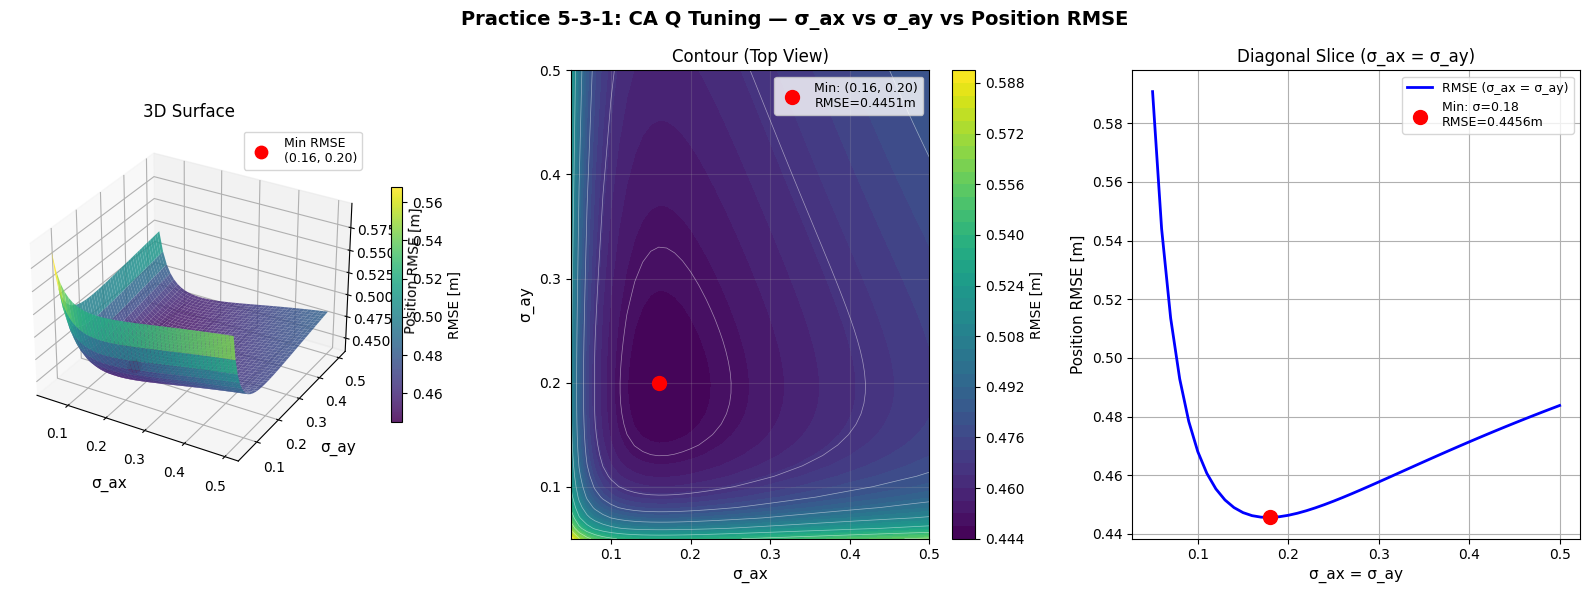

그래프 저장 완료: save_dir = /home/harry/Ai_lab/git/Optimal-State-Estimate-Practice/outputs/CA_Q_tuning_result.png


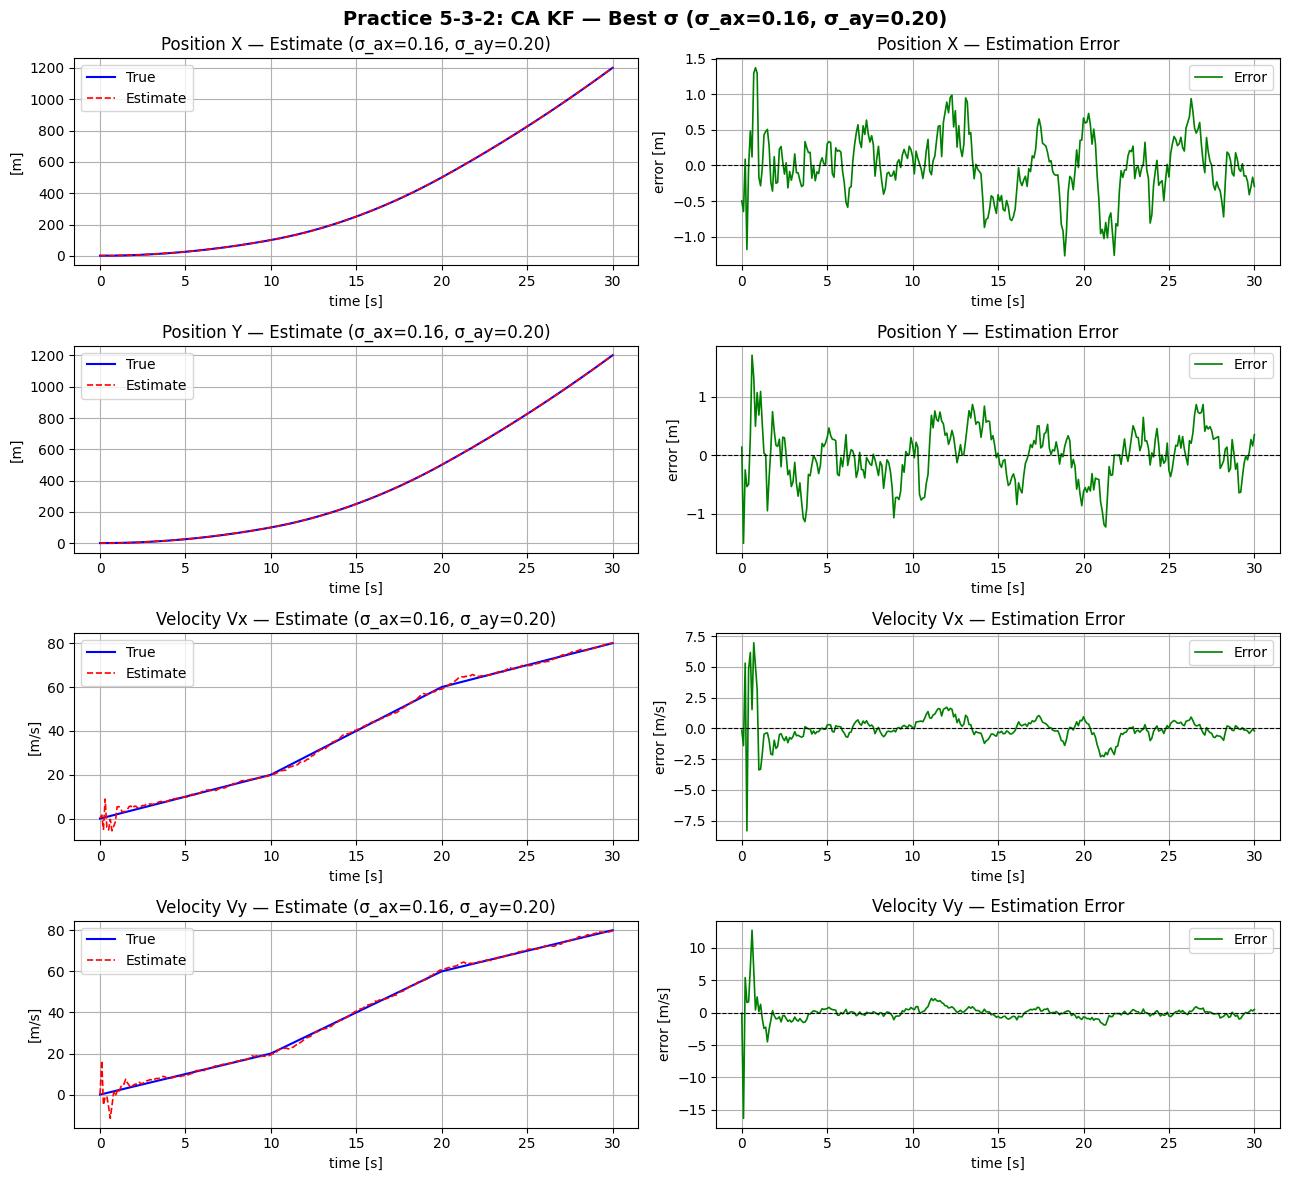

추정 결과 저장 완료: save_dir = /home/harry/Ai_lab/git/Optimal-State-Estimate-Practice/outputs/CA_KF_best_result.png


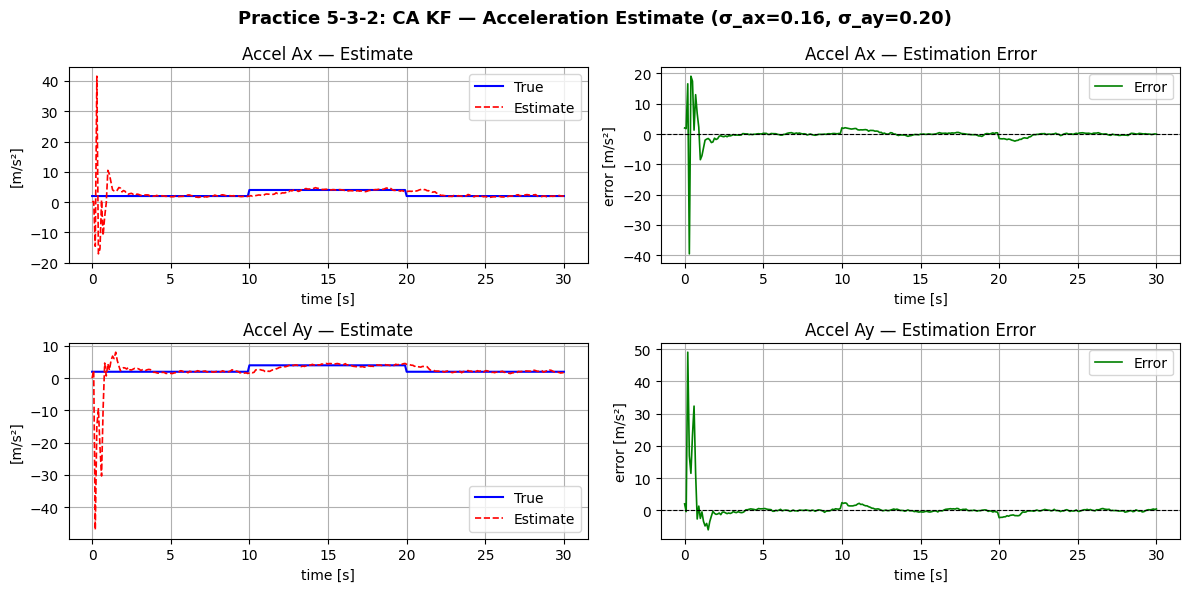

가속도 추정 결과 저장 완료: save_dir = /home/harry/Ai_lab/git/Optimal-State-Estimate-Practice/outputs/CA_accel_result.png

Practice 5-3-3: CA Kalman Filter RMSE
  RMSE Position X  : 0.4396 m
  RMSE Position Y  : 0.4506 m
  RMSE Velocity Vx : 1.1879 m/s
  RMSE Velocity Vy : 1.5540 m/s
  RMSE Accel Ax    : 3.1853 m/s²
  RMSE Accel Ay    : 3.9897 m/s²


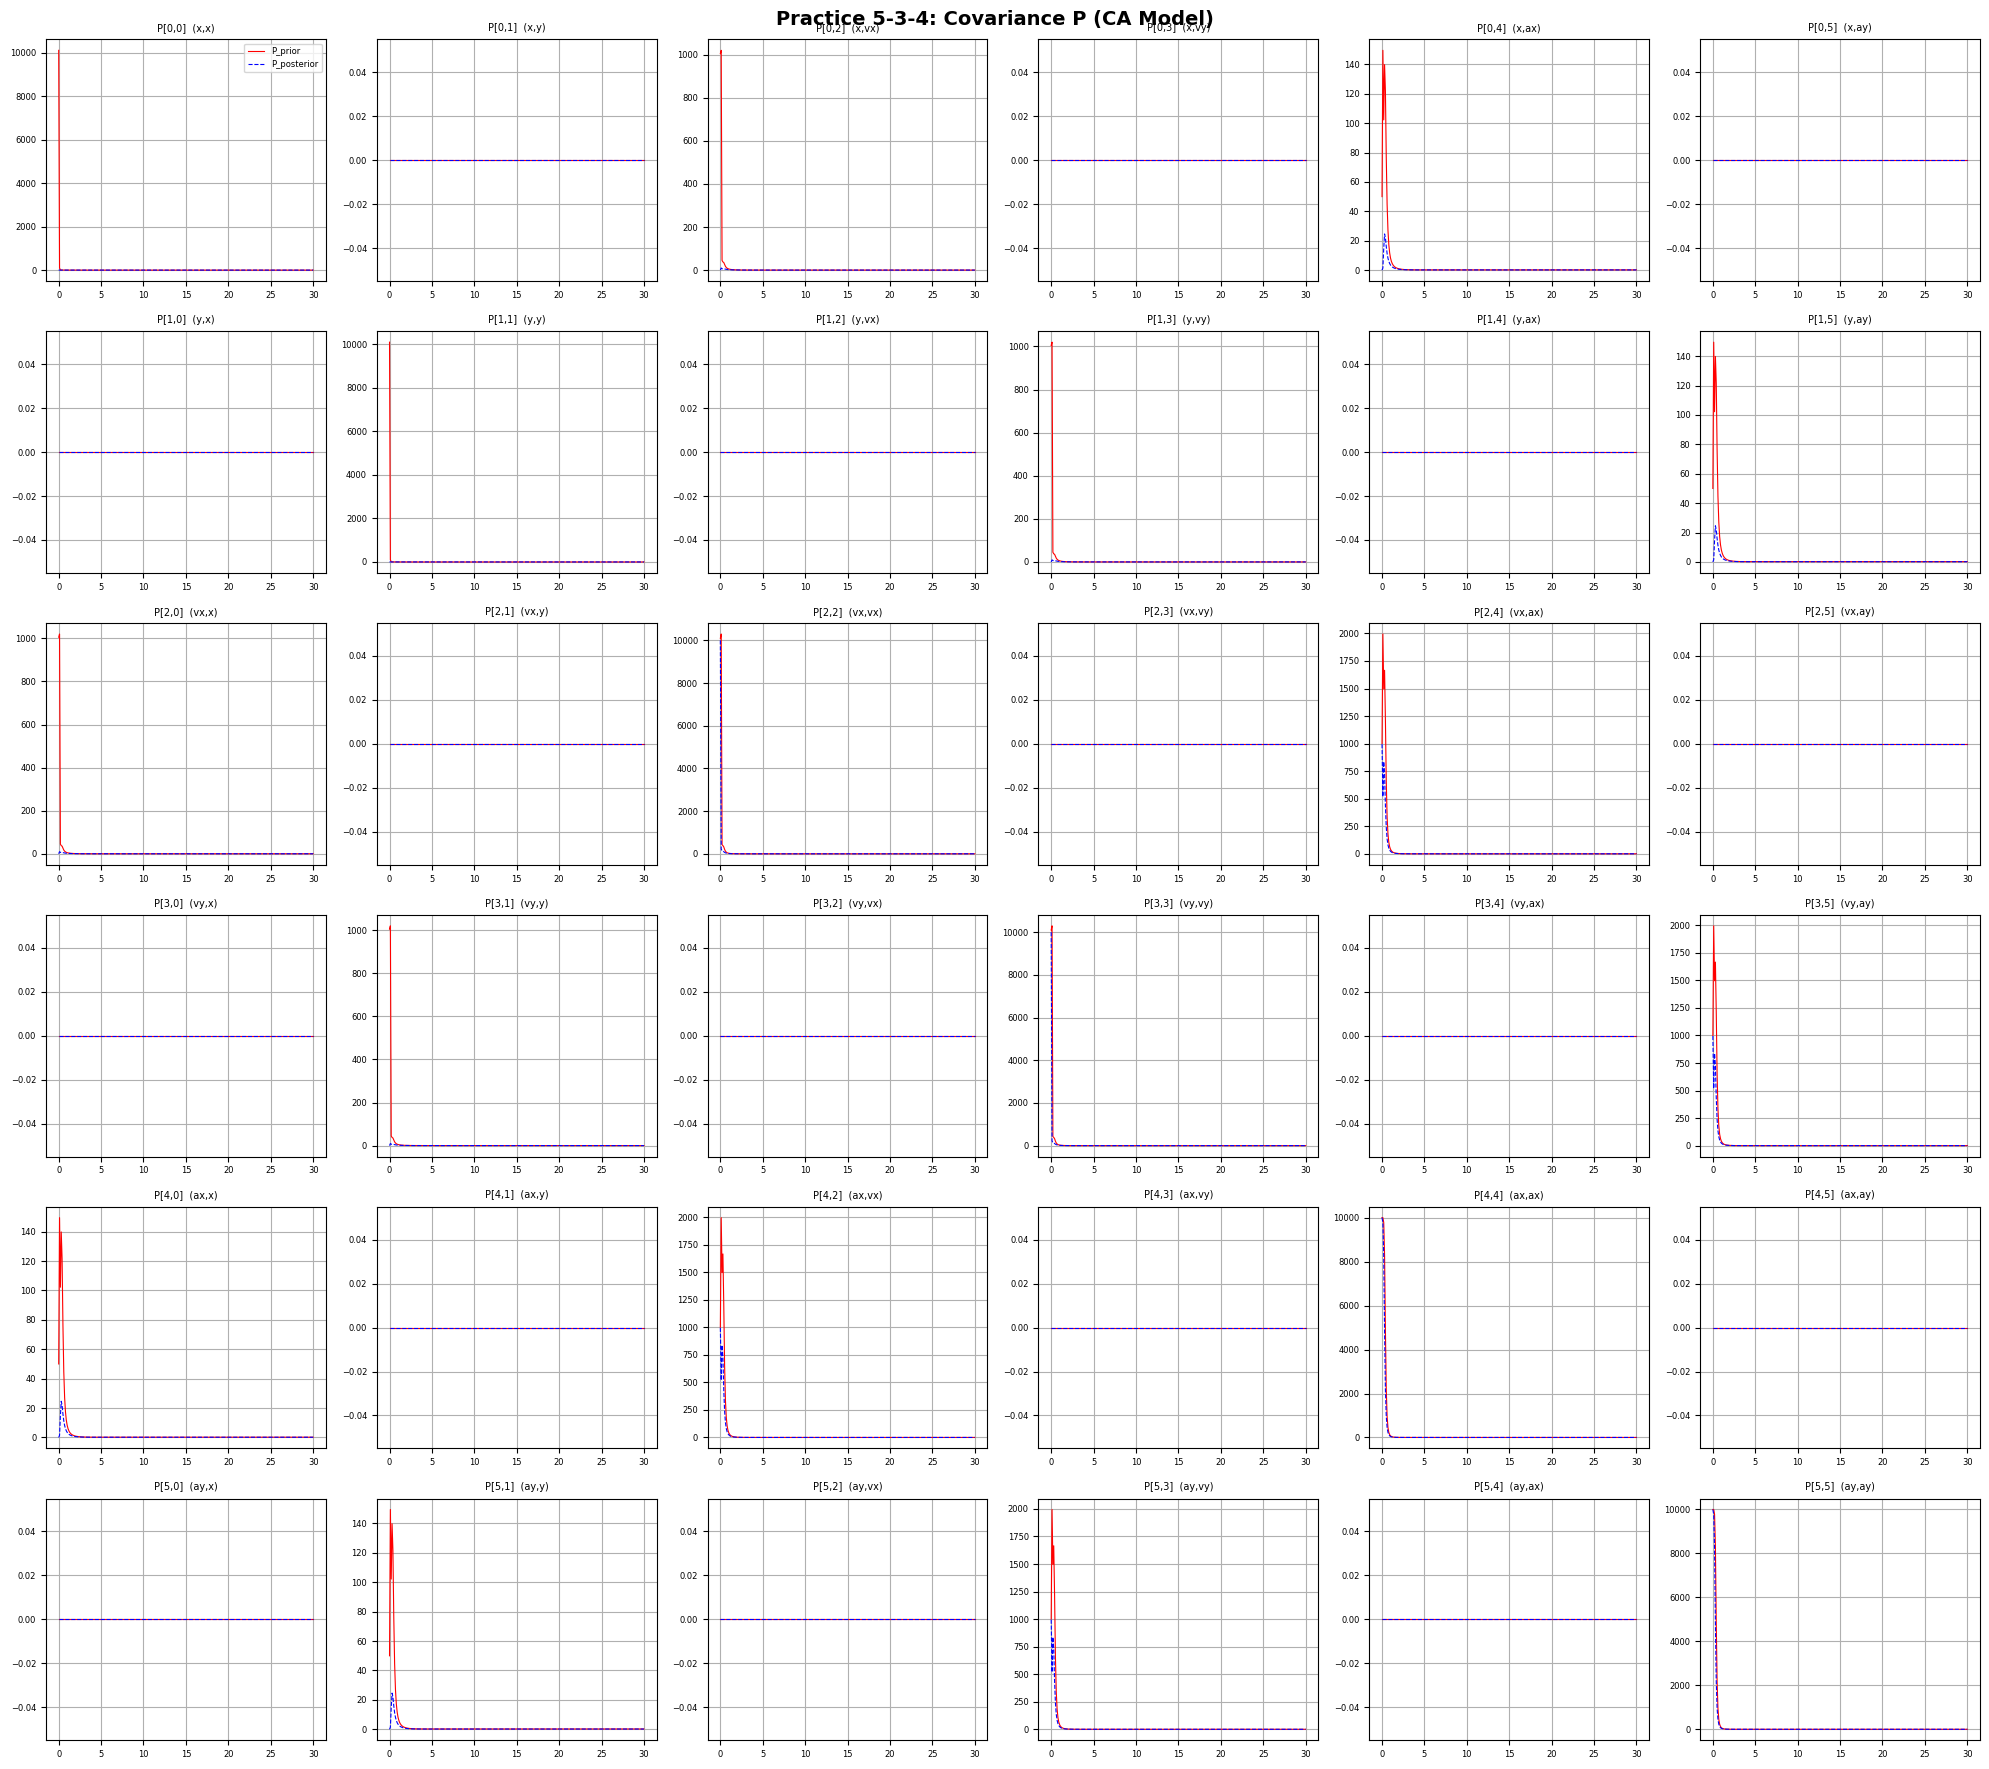

공분산 P 그래프 저장 완료: save_dir = /home/harry/Ai_lab/git/Optimal-State-Estimate-Practice/outputs/CA_P_covariance.png


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import os

# =========================================
# 저장 경로 설정
# =========================================
save_dir = "save_dir = /home/harry/Ai_lab/git/Optimal-State-Estimate-Practice/outputs"
os.makedirs(save_dir, exist_ok=True)

# =========================================
# 공통 파라미터
# =========================================
dT    = 0.1
t_end = 30.0
t     = np.arange(0, t_end + dT, dT)
N     = len(t)
sigma = 1.0          # 측정 노이즈 표준편차 (고정)

# =========================================
# Practice 1-1: True State 시뮬레이션
#   x_k = F_true x_{k-1} + G_true u_{k-1}
#   process noise = 0  (deterministic)
#   상태: [x, y, vx, vy]^T  (4차원)
# =========================================
F_true = np.array([[1.0, 0.0, dT,  0.0],
                   [0.0, 1.0, 0.0, dT ],
                   [0.0, 0.0, 1.0, 0.0],
                   [0.0, 0.0, 0.0, 1.0]])

G_true = np.array([[dT**2/2, 0.0    ],
                   [0.0,     dT**2/2],
                   [dT,      0.0    ],
                   [0.0,     dT     ]])

# =========================================
# 구간별 가속도 입력 (Practice 1과 동일)
# =========================================
def get_acceleration(time):
    if time < 10.0:
        return np.array([2.0, 2.0])
    elif time < 20.0:
        return np.array([4.0, 4.0])
    else:
        return np.array([2.0, 2.0])

# =========================================
# True state 생성
# =========================================
x0    = np.array([[1.0], [1.0], [0.0], [0.0]])
x_true = np.zeros((N, 4))
x_curr = x0.copy()

for k in range(N):
    x_true[k] = x_curr.flatten()
    u          = get_acceleration(t[k]).reshape(2, 1)
    x_curr     = F_true @ x_curr + G_true @ u

# =========================================
# Practice 1-2: 측정값 생성
#   y_k = H x_k + v_k,  v_k ~ N(0, R)
#   seed=42 고정 (CV 코드와 동일한 측정값 사용)
# =========================================
np.random.seed(42)

# H: 위치(x, y)만 측정 — CA 모델에서도 측정 모델은 동일
# CA 모델의 H는 (2×6) 이지만, 측정값 생성은 true state(4차원)에서
H_true = np.array([[1.0, 0.0, 0.0, 0.0],
                   [0.0, 1.0, 0.0, 0.0]])   # true state용 (2×4)

y_history = np.zeros((N, 2))
for k in range(N):
    noise        = np.random.normal(0, sigma, size=2)
    y_history[k] = H_true @ x_true[k] + noise

# =========================================
# R: Measurement noise covariance
#    Practice 1-2 센서 사양 (표준편차 1m, X·Y 독립)
#    CV와 동일하게 고정 — 모델이 바뀌어도 센서는 그대로
# =========================================
R = np.array([[sigma**2, 0.0     ],
              [0.0,      sigma**2]])   # (2×2), 고정값

# =========================================
# CA 모델 행렬 정의
#   상태: [x, y, vx, vy, ax, ay]^T  (6차원)  ← CV의 4차원과 차이
#
#   F_ca (6×6): 등가속도 가정
#     x_{k+1}  = x_k  + vx_k·dT + (1/2)·ax_k·dT²
#     vx_{k+1} = vx_k + ax_k·dT
#     ax_{k+1} = ax_k              ← 가속도 일정 가정
#
#   H_ca (2×6): 위치만 측정 (가속도 열 추가)
# =========================================
F_ca = np.array([
    [1.0, 0.0, dT,  0.0, dT**2/2, 0.0    ],   # x
    [0.0, 1.0, 0.0, dT,  0.0,     dT**2/2],   # y
    [0.0, 0.0, 1.0, 0.0, dT,      0.0    ],   # vx
    [0.0, 0.0, 0.0, 1.0, 0.0,     dT     ],   # vy
    [0.0, 0.0, 0.0, 0.0, 1.0,     0.0    ],   # ax  ← 가속도 일정 가정
    [0.0, 0.0, 0.0, 0.0, 0.0,     1.0    ],   # ay
])   # (6×6)

H_ca = np.array([
    [1.0, 0.0, 0.0, 0.0, 0.0, 0.0],   # x 측정
    [0.0, 1.0, 0.0, 0.0, 0.0, 0.0],   # y 측정
])   # (2×6)  ← CV의 (2×4)에서 0 열 두 개 추가

# =========================================
# G_ca (6×2): 가속도 변화율(jerk)이 상태에 미치는 영향
#   CV 모델: G(4×2) — 가속도 전체를 흡수
#   CA 모델: G(6×2) — 가속도 변화율(jerk)만 흡수
#     위치:  (1/2)·dT²
#     속도:  dT
#     가속도: 1          ← CV에는 없던 행
# =========================================
G_ca = np.array([
    [dT**2/2, 0.0    ],   # x
    [0.0,     dT**2/2],   # y
    [dT,      0.0    ],   # vx
    [0.0,     dT     ],   # vy
    [1.0,     0.0    ],   # ax  ← CV에 없던 행
    [0.0,     1.0    ],   # ay  ← CV에 없던 행
])   # (6×2)

# =========================================
# CA Kalman Filter 함수
#   입력:  sigma_ax, sigma_ay
#   출력:  rmse_pos (position 대표 RMSE)
#          rmse     ([x, y, vx, vy] RMSE)
#          ※ 가속도 RMSE는 별도 계산 (sweep 시 제외)
# =========================================
def run_kf_ca(sigma_ax, sigma_ay):

    # -----------------------------------------
    # Q = G_ca · Qv · G_ca^T  (6×6)
    #   CV: Q(4×4) = G(4×2) · Qv(2×2) · G^T(2×4)
    #   CA: Q(6×6) = G(6×2) · Qv(2×2) · G^T(2×6)
    #   → 구조 동일, 차원만 확장
    # -----------------------------------------
    Qv = np.diag([sigma_ax**2, sigma_ay**2])   # (2×2)
    Q  = G_ca @ Qv @ G_ca.T                    # (6×6)

    I6    = np.eye(6)
    x_hat = np.zeros((6, 1))           # 초기 추정: [0,0,0,0,0,0]^T  ← CV는 4차원
    P     = np.diag([10000.0] * 6)     # 초기 공분산: 10000·I6       ← CV는 I4

    x_hat_log = np.zeros((N, 6))       # 6차원 상태 저장             ← CV는 4차원

    for k in range(N):
        # =====================================
        # 1) Prediction
        # =====================================
        x_hat = F_ca @ x_hat                    # (6×1) = (6×6)@(6×1)
        P     = F_ca @ P @ F_ca.T + Q           # (6×6)

        # =====================================
        # 2) Measurement Update
        # =====================================
        y_k        = y_history[k].reshape(2, 1)
        S          = H_ca @ P @ H_ca.T + R      # (2×2)
        K          = P @ H_ca.T @ np.linalg.inv(S)  # (6×2) ← CV는 (4×2)
        innovation = y_k - H_ca @ x_hat         # (2×1)

        x_hat = x_hat + K @ innovation          # (6×1)
        P     = (I6 - K @ H_ca) @ P             # (6×6)

        x_hat_log[k] = x_hat.flatten()

    # -----------------------------------------
    # RMSE 계산
    #   x_true: (N, 4) — [x, y, vx, vy]
    #   x_hat_log[:, :4]: CA 추정의 앞 4개 성분
    #   → 위치·속도만 비교 (true state는 가속도 없음)
    # -----------------------------------------
    rmse     = np.sqrt(np.mean((x_true - x_hat_log[:, :4])**2, axis=0))
    rmse_pos = np.sqrt(np.mean(rmse[:2]**2))   # 위치 RMSE 대표값

    return rmse_pos, rmse, x_hat_log

# =========================================
# Sigma grid search
#   σ_ax, σ_ay: 0.2 단위로 탐색
#   범위: 0.2 ~ 10.0  ← CA는 CV(1~20)보다 작을 가능성 있음
# =========================================
sigma_vals = np.arange(0.05, 0.5 + 0.01, 0.01)
n_pts      = len(sigma_vals)

sigma_AX, sigma_AY = np.meshgrid(sigma_vals, sigma_vals)
RMSE_grid = np.zeros((n_pts, n_pts))

print("CA 모델 Q 튜닝 sweep 시작...")
print(f"  σ_ax, σ_ay: {n_pts} × {n_pts} = {n_pts**2} 조합 탐색")
print(f"  탐색 범위: {sigma_vals[0]:.1f} ~ {sigma_vals[-1]:.1f}")
print("  탐색 간격: 0.01")

for i, sax in enumerate(sigma_vals):
    for j, say in enumerate(sigma_vals):
        rmse_pos, _, _ = run_kf_ca(sax, say)
        RMSE_grid[j, i] = rmse_pos

    if (i + 1) % 10 == 0:
        print(f"  [{i+1}/{n_pts}] σ_ax = {sax:.2f} 완료")

print("Sweep 완료!")

# =========================================
# 최적 / 최악 조합 탐색
# =========================================
min_idx   = np.unravel_index(np.argmin(RMSE_grid), RMSE_grid.shape)
best_say  = sigma_vals[min_idx[0]]
best_sax  = sigma_vals[min_idx[1]]
best_rmse = RMSE_grid[min_idx]

max_idx    = np.unravel_index(np.argmax(RMSE_grid), RMSE_grid.shape)
worst_say  = sigma_vals[max_idx[0]]
worst_sax  = sigma_vals[max_idx[1]]
worst_rmse = RMSE_grid[max_idx]

print("\n" + "=" * 50)
print("Practice 5-3: CA 최적 σ 조합 탐색 결과")
print("=" * 50)
print(f"  최적 σ_ax  = {best_sax:.4f}")
print(f"  최적 σ_ay  = {best_say:.4f}")
print(f"  최소 RMSE  = {best_rmse:.6f} m")
print("=" * 50)
print(f"  최악 σ_ax  = {worst_sax:.4f}")
print(f"  최악 σ_ay  = {worst_say:.4f}")
print(f"  최대 RMSE  = {worst_rmse:.6f} m")
print("=" * 50)

# 최적 조합으로 상세 RMSE 재계산
_, best_rmse_detail, best_x_hat_log = run_kf_ca(best_sax, best_say)

print("\n최적 조합으로 상세 RMSE 재계산")
print(f"  RMSE x   = {best_rmse_detail[0]:.4f} m")
print(f"  RMSE y   = {best_rmse_detail[1]:.4f} m")
print(f"  RMSE vx  = {best_rmse_detail[2]:.4f} m/s")
print(f"  RMSE vy  = {best_rmse_detail[3]:.4f} m/s")

# 가속도 RMSE 별도 계산
#   true 가속도는 구간별로 알려진 값 → 직접 배열 생성
a_true = np.array([get_acceleration(t[k]) for k in range(N)])   # (N, 2)
rmse_ax = np.sqrt(np.mean((a_true[:, 0] - best_x_hat_log[:, 4])**2))
rmse_ay = np.sqrt(np.mean((a_true[:, 1] - best_x_hat_log[:, 5])**2))
print(f"  RMSE ax  = {rmse_ax:.4f} m/s²")
print(f"  RMSE ay  = {rmse_ay:.4f} m/s²")

# =========================================
# 3D Surface Plot (Practice 2와 동일 구조)
# =========================================
fig = plt.figure(figsize=(16, 6))
fig.suptitle("Practice 5-3-1: CA Q Tuning — σ_ax vs σ_ay vs Position RMSE",
             fontsize=14, fontweight="bold")

# (1) 3D Surface
ax1 = fig.add_subplot(131, projection="3d")
surf = ax1.plot_surface(sigma_AX, sigma_AY, RMSE_grid,
                        cmap=cm.viridis, alpha=0.85, linewidth=0)
ax1.scatter([best_sax], [best_say], [best_rmse],
            color="red", s=80, zorder=5,
            label=f"Min RMSE\n({best_sax:.2f}, {best_say:.2f})")
ax1.set_xlabel("σ_ax", fontsize=11, labelpad=8)
ax1.set_ylabel("σ_ay", fontsize=11, labelpad=8)
ax1.set_zlabel("Position RMSE [m]", fontsize=10, labelpad=8)
ax1.set_title("3D Surface", fontsize=12)
ax1.legend(fontsize=9, loc="upper right")
fig.colorbar(surf, ax=ax1, shrink=0.5, label="RMSE [m]")

# (2) Contour
ax2 = fig.add_subplot(132)
cp = ax2.contourf(sigma_AX, sigma_AY, RMSE_grid, levels=40, cmap="viridis")
ax2.contour(sigma_AX, sigma_AY, RMSE_grid,
            levels=10, colors="white", linewidths=0.5, alpha=0.5)
ax2.scatter(best_sax, best_say, color="red", s=100, zorder=5,
            label=f"Min: ({best_sax:.2f}, {best_say:.2f})\nRMSE={best_rmse:.4f}m")
ax2.set_xlabel("σ_ax", fontsize=11)
ax2.set_ylabel("σ_ay", fontsize=11)
ax2.set_title("Contour (Top View)", fontsize=12)
ax2.legend(fontsize=9, loc="upper right")
ax2.grid(True, alpha=0.2)
fig.colorbar(cp, ax=ax2, label="RMSE [m]")

# (3) Diagonal Slice
ax3 = fig.add_subplot(133)
diag_rmse    = np.array([run_kf_ca(s, s)[0] for s in sigma_vals])
diag_min_idx = np.argmin(diag_rmse)
ax3.plot(sigma_vals, diag_rmse, "b-", linewidth=2,
         label="RMSE (σ_ax = σ_ay)")
ax3.scatter(sigma_vals[diag_min_idx], diag_rmse[diag_min_idx],
            color="red", s=100, zorder=5,
            label=f"Min: σ={sigma_vals[diag_min_idx]:.2f}\nRMSE={diag_rmse[diag_min_idx]:.4f}m")
ax3.set_xlabel("σ_ax = σ_ay", fontsize=11)
ax3.set_ylabel("Position RMSE [m]", fontsize=11)
ax3.set_title("Diagonal Slice (σ_ax = σ_ay)", fontsize=12)
ax3.legend(fontsize=9)
ax3.grid(True)

plt.tight_layout()
q_path = os.path.join(save_dir, "CA_Q_tuning_result.png")
plt.savefig(q_path, dpi=150, bbox_inches="tight")
plt.show()
print("그래프 저장 완료:", q_path)

# =========================================
# 최적 σ로 KF 재실행 — 전체 결과 저장
#   (sweep 시에는 RMSE만 저장했으므로 재실행)
# =========================================
Qv_best = np.diag([best_sax**2, best_say**2])
Q_best  = G_ca @ Qv_best @ G_ca.T   # (6×6)

x_hat   = np.zeros((6, 1))
P_mat   = np.diag([10000.0] * 6)
I6      = np.eye(6)

x_hat_log   = np.zeros((N, 6))
P_prior_log = np.zeros((N, 6, 6))
P_post_log  = np.zeros((N, 6, 6))

for k in range(N):
    # Predict
    x_hat = F_ca @ x_hat
    P_mat = F_ca @ P_mat @ F_ca.T + Q_best
    P_prior_log[k] = P_mat

    # Update
    y_k   = y_history[k].reshape(2, 1)
    S     = H_ca @ P_mat @ H_ca.T + R
    K     = P_mat @ H_ca.T @ np.linalg.inv(S)
    x_hat = x_hat + K @ (y_k - H_ca @ x_hat)
    P_mat = (I6 - K @ H_ca) @ P_mat

    P_post_log[k] = P_mat
    x_hat_log[k]  = x_hat.flatten()

# =========================================
# Practice 3-2: 추정 상태 + 오차 Plot
#   x, y, vx, vy 4개 (가속도는 별도)
# =========================================
fig2, axes = plt.subplots(4, 2, figsize=(13, 12))
labels = ["Position X", "Position Y", "Velocity Vx", "Velocity Vy"]
units  = ["m", "m", "m/s", "m/s"]

for i in range(4):
    axes[i, 0].plot(t, x_true[:, i],      "b-",  label="True",     linewidth=1.5)
    axes[i, 0].plot(t, x_hat_log[:, i],   "r--", label="Estimate", linewidth=1.2)
    axes[i, 0].set_title(f"{labels[i]} — Estimate (σ_ax={best_sax:.2f}, σ_ay={best_say:.2f})")
    axes[i, 0].set_xlabel("time [s]")
    axes[i, 0].set_ylabel(f"[{units[i]}]")
    axes[i, 0].legend()
    axes[i, 0].grid(True)

    error = x_true[:, i] - x_hat_log[:, i]
    axes[i, 1].plot(t, error, "g-", linewidth=1.2, label="Error")
    axes[i, 1].axhline(0, color="k", linewidth=0.8, linestyle="--")
    axes[i, 1].set_title(f"{labels[i]} — Estimation Error")
    axes[i, 1].set_xlabel("time [s]")
    axes[i, 1].set_ylabel(f"error [{units[i]}]")
    axes[i, 1].legend()
    axes[i, 1].grid(True)

plt.suptitle(f"Practice 5-3-2: CA KF — Best σ (σ_ax={best_sax:.2f}, σ_ay={best_say:.2f})",
             fontsize=14, fontweight="bold")
plt.tight_layout()
est_path = os.path.join(save_dir, "CA_KF_best_result.png")
plt.savefig(est_path, dpi=150, bbox_inches="tight")
plt.show()
print("추정 결과 저장 완료:", est_path)

# =========================================
# 가속도 추정 결과 별도 Plot
# =========================================
fig3, axes3 = plt.subplots(2, 2, figsize=(12, 6))

for i, (label, unit, col, true_a) in enumerate([
    ("Accel Ax", "m/s²", 4, a_true[:, 0]),
    ("Accel Ay", "m/s²", 5, a_true[:, 1]),
]):
    axes3[i, 0].plot(t, true_a,              "b-",  label="True",     linewidth=1.5)
    axes3[i, 0].plot(t, x_hat_log[:, col],   "r--", label="Estimate", linewidth=1.2)
    axes3[i, 0].set_title(f"{label} — Estimate")
    axes3[i, 0].set_xlabel("time [s]")
    axes3[i, 0].set_ylabel(f"[{unit}]")
    axes3[i, 0].legend()
    axes3[i, 0].grid(True)

    error = true_a - x_hat_log[:, col]
    axes3[i, 1].plot(t, error, "g-", linewidth=1.2, label="Error")
    axes3[i, 1].axhline(0, color="k", linewidth=0.8, linestyle="--")
    axes3[i, 1].set_title(f"{label} — Estimation Error")
    axes3[i, 1].set_xlabel("time [s]")
    axes3[i, 1].set_ylabel(f"error [{unit}]")
    axes3[i, 1].legend()
    axes3[i, 1].grid(True)

plt.suptitle(f"Practice 5-3-2: CA KF — Acceleration Estimate (σ_ax={best_sax:.2f}, σ_ay={best_say:.2f})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
accel_path = os.path.join(save_dir, "CA_accel_result.png")
plt.savefig(accel_path, dpi=150, bbox_inches="tight")
plt.show()
print("가속도 추정 결과 저장 완료:", accel_path)

# =========================================
# Practice 3-3: RMSE 출력
# =========================================
print("\n" + "=" * 50)
print("Practice 5-3-3: CA Kalman Filter RMSE")
print("=" * 50)
print(f"  RMSE Position X  : {best_rmse_detail[0]:.4f} m")
print(f"  RMSE Position Y  : {best_rmse_detail[1]:.4f} m")
print(f"  RMSE Velocity Vx : {best_rmse_detail[2]:.4f} m/s")
print(f"  RMSE Velocity Vy : {best_rmse_detail[3]:.4f} m/s")
print(f"  RMSE Accel Ax    : {rmse_ax:.4f} m/s²")
print(f"  RMSE Accel Ay    : {rmse_ay:.4f} m/s²")
print("=" * 50)

# =========================================
# Practice 3-4: 공분산 P plot
#   P: 6×6 → P[0,0]~P[5,5] 대각 성분
#   사전(P_prior) / 사후(P_post) 둘 다
# =========================================
fig4, axes4 = plt.subplots(6, 6, figsize=(20, 18))
state_labels = ["x", "y", "vx", "vy", "ax", "ay"]

for i in range(6):
    for j in range(6):
        axes4[i, j].plot(t, P_prior_log[:, i, j], "r-",  label="P_prior",     linewidth=0.8)
        axes4[i, j].plot(t, P_post_log[:, i, j],  "b--", label="P_posterior", linewidth=0.8)
        axes4[i, j].set_title(f"P[{i},{j}]  ({state_labels[i]},{state_labels[j]})", fontsize=7)
        axes4[i, j].grid(True)
        axes4[i, j].tick_params(labelsize=6)
        if i == 0 and j == 0:
            axes4[i, j].legend(fontsize=6)

plt.suptitle("Practice 5-3-4: Covariance P (CA Model)", fontsize=14, fontweight="bold")
plt.tight_layout()
p_path = os.path.join(save_dir, "CA_P_covariance.png")
plt.savefig(p_path, dpi=120, bbox_inches="tight")
plt.show()
print("공분산 P 그래프 저장 완료:", p_path)

# 📋 Practice 5-3-1. CA Process Model 유도

## ■ 목표
- 가속도까지 상태에 포함시킨 **CA (Constant Acceleration)** 모델의 process model을 직접 유도
- F 행렬 (6×6)을 손으로 작성

---

## ■ CA 모델 상태 정의

CV 모델 (4차원)에서 **가속도 2개**를 추가:

```
x_t = [x, y, v_x, v_y, a_x, a_y]ᵀ        (6차원)
```

> 이제 가속도가 외부 입력(u)이 아니라 **상태(state)** 의 일부

---

## ■ 운동방정식 유도

### 1️⃣ 위치 업데이트 (등가속도 운동)
```
x_{t+1}   = x_t + v_x · dT + ½ · a_x · dT²
y_{t+1}   = y_t + v_y · dT + ½ · a_y · dT²
```

### 2️⃣ 속도 업데이트
```
v_x_{t+1} = v_x_t + a_x · dT
v_y_{t+1} = v_y_t + a_y · dT
```

### 3️⃣ 가속도 업데이트 (등가속 가정 → 변하지 않음)
```
a_x_{t+1} = a_x_t
a_y_{t+1} = a_y_t
```

> 등가속 가정이지만, 실제로는 process noise w_t가 가속도 변화를 흡수

---

## ■ 행렬 형태 (F 행렬, 6×6)

```
        ┌  x   ┐         ┌ 1  0  dT  0   ½dT²    0   ┐  ┌  x   ┐
        │  y   │         │ 0  1  0   dT   0    ½dT² │  │  y   │
        │ v_x  │     =   │ 0  0  1   0   dT     0   │  │ v_x  │
        │ v_y  │         │ 0  0  0   1   0     dT   │  │ v_y  │
        │ a_x  │         │ 0  0  0   0   1      0   │  │ a_x  │
        └ a_y  ┘_{t+1}   └ 0  0  0   0   0      1   ┘  └ a_y  ┘_t
```

```
x_{t+1} = F_CA · x_t + w_t,    w_t ~ N(0, Q)
```

---

## ■ Measurement Model

측정은 여전히 **위치만** (CV 모델과 동일):

```
            ┌ 1  0  0  0  0  0 ┐
   H_CA  =  │                  │       (2 × 6)
            └ 0  1  0  0  0  0 ┘
```

```
y_t = H_CA · x_t + r_t,    r_t ~ N(0, R)
```

---

## ■ Q 행렬 설계 방향 (간단 버전)

CA 모델은 가속도가 상태에 있으므로, process noise는 **가속도가 시간에 따라 약간씩 변하는 것**을 모델링:

```
Q = diag(σ_x², σ_y², σ_vx², σ_vy², σ_ax², σ_ay²)        (6 × 6)
```

> 실용적으로는 위치/속도 노이즈는 작게, 가속도 노이즈만 적당히 두는 방식
> 예: `Q = diag(0.01, 0.01, 0.01, 0.01, 1.0, 1.0)`
> 튜닝 변수: 가속도 노이즈 σ_ax, σ_ay

---

## ■ CV vs CA 비교 (구조적 차이)

|  항목       |    CV 모델            |    CA 모델            |
|-------------|----------------------|----------------------|
| 상태 차원   | 4                    | **6**                |
| 가속도 처리 | 외부 입력 / Q에 흡수 | **상태에 포함**      |
| F 행렬 크기 | 4×4                  | 6×6                  |
| H 행렬 크기 | 2×4                  | 2×6                  |
| P 행렬 크기 | 4×4 (16 원소)        | 6×6 (36 원소)        |

---

## ■ 한줄 정리

> 👉 "가속도를 상태에 포함시켜, 칼만필터가 위치·속도뿐 아니라 **가속도까지 추정**할 수 있게 만든 모델"
> 👉 가속도 변화에 더 빠르게 반응 가능 → CV의 약점(가속도 변화 시 추정 지연) 보완 기대

---

## 💡 핵심 직관

- CV 모델: "가속도는 모름, 그냥 노이즈로 처리"
- CA 모델: "가속도도 추정해야 할 대상으로 보고, 측정값으로부터 역추정"
- → CA가 더 정교하지만, 상태가 많아지면 P 행렬이 커지고 튜닝이 어려워짐

# 📋 Practice 5-3-2 ~ 4. Kalman Filter with CA (Constant Acceleration) Model

## ■ 목표
- 5-3-1에서 유도한 CA 모델로 칼만필터 적용
- 가속도까지 상태에 포함 → 가속도 변화에 빠르게 반응 기대
- CV 모델과 비교했을 때 RMSE가 줄어드는지 확인

## ■ CA Process Model

```
x_t = [x, y, v_x, v_y, a_x, a_y]ᵀ        (6차원)
```

```
        ┌ 1  0  dT  0   ½dT²    0   ┐
        │ 0  1  0   dT   0    ½dT² │
   F =  │ 0  0  1   0   dT     0   │     (6 × 6)
        │ 0  0  0   1   0     dT   │
        │ 0  0  0   0   1      0   │
        └ 0  0  0   0   0      1   ┘
```

## ■ Measurement Model

```
        ┌ 1  0  0  0  0  0 ┐
   H =  │                  │            (2 × 6)
        └ 0  1  0  0  0  0 ┘
```

## ■ Q, R, 초기 조건

- Q (6×6): 가속도 process noise 위주로 튜닝
  - 예: `Q = diag(0.01, 0.01, 0.01, 0.01, σ_a², σ_a²)`
- R (2×2): CV와 동일 (`σ² = 1`)
- x_0: [0, 0, 0, 0, 0, 0]ᵀ
- P_0: diag(10000, 10000, 10000, 10000, 10000, 10000)

## ■ 풀이 절차

### 1️⃣ CA 모델용 행렬 정의
- F (6×6), H (2×6), Q (6×6), R (2×2)

### 2️⃣ 초기 조건 설정
- x_0 (6×1), P_0 (6×6)

### 3️⃣ 칼만필터 루프 (5-2와 동일 구조, 차원만 다름)
- Prediction → x̂⁻, P⁻
- Update → K, x̂⁺, P⁺

### 4️⃣ 결과 시각화 (5-3-2)
- 추정 상태 6개 plot (x, y, v_x, v_y, a_x, a_y)
- 추정 오차 plot

### 5️⃣ RMSE 계산 (5-3-3)
- 6개 상태 각각의 RMSE
- 가속도 RMSE 비교 (CV는 가속도 추정 자체가 없음)

### 6️⃣ 공분산 P plot (5-3-4)
- P 행렬 6×6 = 36개 원소

---

## ■ 한줄 정리

> 👉 "가속도까지 상태에 포함시킨 CA 칼만필터로 위치/속도/가속도를 동시 추정"
> 👉 CV 대비 가속도 변화 구간에서 추정 성능이 개선되는지 확인

---

## 💡 헷갈리기 쉬운 포인트

- **상태 차원이 6으로 커짐**: F (6×6), P (6×6) → 코드 차원 주의
- **참값 비교 시 가속도**: x_history는 4차원이라 가속도가 없음
  → 따로 만들어둔 `a_x`, `a_y` 배열과 비교 필요
- **Q 튜닝**: 위치/속도 항은 작게, 가속도 항은 적당히
  → CA 모델의 핵심은 "가속도가 일정하지 않을 수 있다"는 것을 Q로 표현
- **F 행렬 작성 시 ½dT² 위치**: 1열(x)→5열(a_x), 2열(y)→6열(a_y)에만 들어감

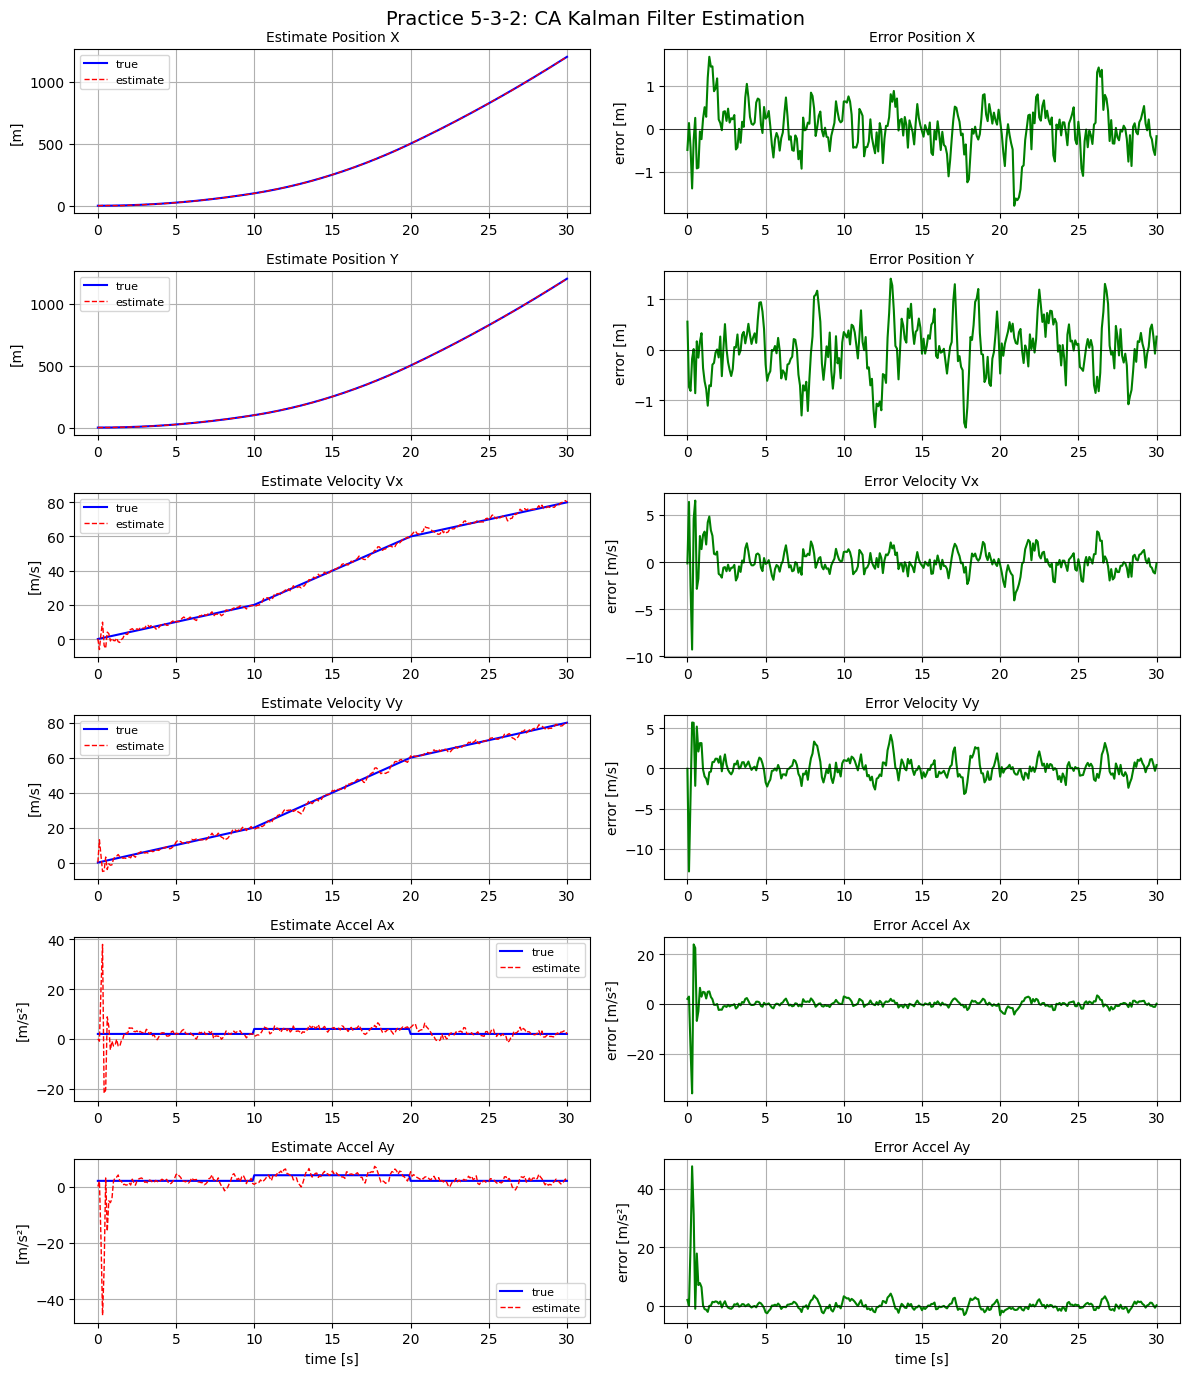

Practice 5-3-3: CA Kalman Filter RMSE
RMSE Position X    : 0.5301 m
RMSE Position Y    : 0.5361 m
RMSE Velocity Vx   : 1.4487 m/s
RMSE Velocity Vy   : 1.5007 m/s
RMSE Accel Ax      : 3.3408 m/s²
RMSE Accel Ay      : 3.9240 m/s²


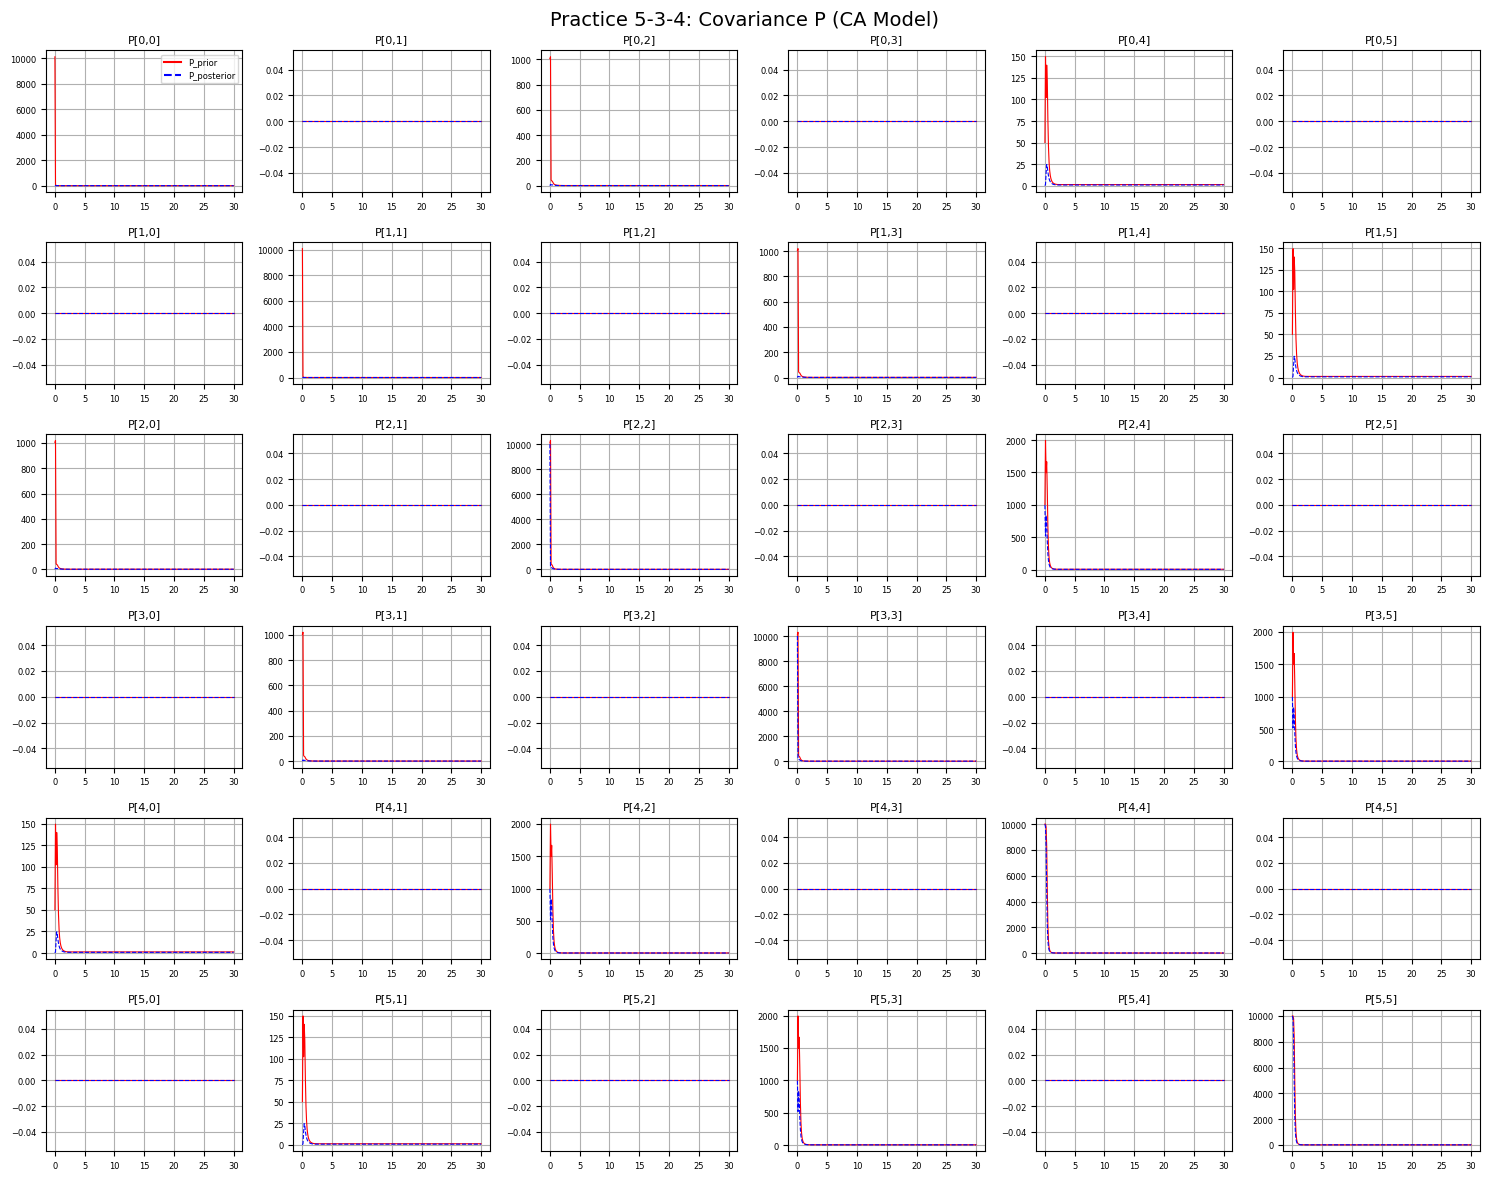

In [4]:
# =========================================
# 1️⃣ CA 모델용 행렬 정의 (6차원 상태)
#    상태: [x, y, vx, vy, ax, ay]
# =========================================
F_ca = np.array([
    [1.0, 0.0, dT,  0.0, 0.5*dT**2, 0.0      ],
    [0.0, 1.0, 0.0, dT,  0.0,       0.5*dT**2],
    [0.0, 0.0, 1.0, 0.0, dT,        0.0      ],
    [0.0, 0.0, 0.0, 1.0, 0.0,       dT       ],
    [0.0, 0.0, 0.0, 0.0, 1.0,       0.0      ],
    [0.0, 0.0, 0.0, 0.0, 0.0,       1.0      ]
])                                        # (6, 6)

H_ca = np.array([[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                 [0.0, 1.0, 0.0, 0.0, 0.0, 0.0]])
                                          # (2, 6)


# =========================================
# 2️⃣ Q 행렬 설계
#    위치/속도 항은 작게, 가속도 항만 적당히
#    → "가속도가 약간씩 변할 수 있다"는 의미
# =========================================
sigma_a_ca = 1.0                          # 가속도 process noise 표준편차

Q_ca = np.diag([0.01, 0.01,               # 위치 노이즈 (작게)
                0.01, 0.01,               # 속도 노이즈 (작게)
                sigma_a_ca**2,            # 가속도 X 노이즈
                sigma_a_ca**2])           # 가속도 Y 노이즈
                                          # (6, 6) 대각행렬


# =========================================
# 3️⃣ R 행렬 설정 (CV와 동일)
#    측정 노이즈 σ = 1 m
# =========================================
R_ca = np.array([[sigma**2, 0.0     ],
                 [0.0,      sigma**2]])  # (2, 2)


# =========================================
# 4️⃣ 초기 조건 설정
#    상태가 6개 → 모두 0으로 시작
# =========================================
x_hat = np.zeros((6, 1))                  # (6, 1) 초기 추정 상태

P = np.diag([10000.0, 10000.0,            # 위치 불확실성 큼
             10000.0, 10000.0,            # 속도 불확실성 큼
             10000.0, 10000.0])           # 가속도 불확실성 큼
                                          # (6, 6)

I_6 = np.eye(6)                           # 6×6 단위행렬


# =========================================
# 5️⃣ 저장 배열 준비
# =========================================
x_hat_ca   = np.zeros((N, 6))             # 추정 상태 6개
P_prior_ca = np.zeros((N, 6, 6))          # 사전 공분산
P_post_ca  = np.zeros((N, 6, 6))          # 사후 공분산


# =========================================
# 6️⃣ 칼만필터 루프 (구조는 5-2와 동일, 차원만 6)
# =========================================
for k in range(N):
    # ---------- Prediction ----------
    x_hat = F_ca @ x_hat                  # (6,1) = (6,6) @ (6,1)
    P     = F_ca @ P @ F_ca.T + Q_ca      # (6,6)
    P_prior_ca[k] = P
    
    # ---------- Update ----------
    y_k = y_history[k].reshape(2, 1)      # (2, 1) 측정값
    
    S = H_ca @ P @ H_ca.T + R_ca          # (2, 2)
    K = P @ H_ca.T @ np.linalg.inv(S)     # (6, 2) Kalman gain
    
    innovation = y_k - H_ca @ x_hat       # (2, 1)
    x_hat = x_hat + K @ innovation        # (6, 1)
    P     = (I_6 - K @ H_ca) @ P          # (6, 6)
    P_post_ca[k] = P
    
    x_hat_ca[k] = x_hat.flatten()


# =========================================
# 7️⃣ Practice 5-3-2: 추정 상태 + 오차 plot
#    상태가 6개라 plot 12개 (3행 × 4열)
# =========================================
# 참값 가속도 배열도 비교용으로 준비
true_states = np.column_stack([
    x_history,                            # x, y, vx, vy (N, 4)
    a_x.reshape(-1, 1),                   # a_x (N, 1)
    a_y.reshape(-1, 1)                    # a_y (N, 1)
])                                        # (N, 6)

labels = ['Position X', 'Position Y',
          'Velocity Vx', 'Velocity Vy',
          'Accel Ax', 'Accel Ay']
units  = ['m', 'm', 'm/s', 'm/s', 'm/s²', 'm/s²']

fig, axes = plt.subplots(6, 2, figsize=(12, 14))

for i in range(6):
    # 좌측: 추정값 vs 참값
    axes[i, 0].plot(t, true_states[:, i], 'b-',  label='true', linewidth=1.5)
    axes[i, 0].plot(t, x_hat_ca[:, i],    'r--', label='estimate', linewidth=1.0)
    axes[i, 0].set_title(f'Estimate {labels[i]}', fontsize=10)
    axes[i, 0].set_ylabel(f'[{units[i]}]')
    axes[i, 0].legend(fontsize=8); axes[i, 0].grid(True)
    
    # 우측: 오차
    error = true_states[:, i] - x_hat_ca[:, i]
    axes[i, 1].plot(t, error, 'g-')
    axes[i, 1].axhline(0, color='k', linewidth=0.5)
    axes[i, 1].set_title(f'Error {labels[i]}', fontsize=10)
    axes[i, 1].set_ylabel(f'error [{units[i]}]')
    axes[i, 1].grid(True)

axes[5, 0].set_xlabel('time [s]')
axes[5, 1].set_xlabel('time [s]')

plt.suptitle('Practice 5-3-2: CA Kalman Filter Estimation', fontsize=14)
plt.tight_layout()
plt.show()


# =========================================
# 8️⃣ Practice 5-3-3: RMSE 계산
# =========================================
rmse_ca = np.zeros(6)
for i in range(6):
    rmse_ca[i] = np.sqrt(np.mean((true_states[:, i] - x_hat_ca[:, i])**2))

print("=" * 50)
print("Practice 5-3-3: CA Kalman Filter RMSE")
print("=" * 50)
for i in range(6):
    print(f"RMSE {labels[i]:14s}: {rmse_ca[i]:.4f} {units[i]}")
print("=" * 50)


# =========================================
# 9️⃣ Practice 5-3-4: 공분산 P plot
#    P 행렬 6×6 = 36개 원소
# =========================================
fig, axes = plt.subplots(6, 6, figsize=(15, 12))

for i in range(6):
    for j in range(6):
        axes[i, j].plot(t, P_prior_ca[:, i, j], 'r-',  linewidth=0.8)
        axes[i, j].plot(t, P_post_ca[:, i, j],  'b--', linewidth=0.8)
        axes[i, j].set_title(f'P[{i},{j}]', fontsize=8)
        axes[i, j].grid(True)
        axes[i, j].tick_params(labelsize=6)

# 범례는 한 곳에만
axes[0, 0].plot([], [], 'r-',  label='P_prior')
axes[0, 0].plot([], [], 'b--', label='P_posterior')
axes[0, 0].legend(fontsize=6, loc='upper right')

plt.suptitle('Practice 5-3-4: Covariance P (CA Model)', fontsize=14)
plt.tight_layout()
plt.show()

 다음 단계 (5-3-5)에서 사용할 변수

- x_hat_cv, x_hat_ca ← 두 모델 추정 결과 비교
- rmse_x, rmse_y, rmse_vx, rmse_vy (CV) ← 비교용
- rmse_ca (CA) ← 비교용

# 📋 Practice 5-3-5. CV vs CA 성능 비교 분석

## ■ 목표
- 5-2 (CV)와 5-3 (CA) 칼만필터의 추정 성능을 직접 비교
- 어떤 모델이 어떤 상황에서 우수한지 정량적/정성적으로 분석
- 모델 선택의 trade-off 이해

## ■ 비교 항목

### 1️⃣ 정량적 비교 (RMSE)
- 4개 공통 상태 (x, y, v_x, v_y)에 대한 RMSE 비교
- 표 형태로 정리

### 2️⃣ 정성적 비교 (Plot)
- 추정값 시간 그래프를 한 화면에 겹쳐 그리기
- 특히 **가속도 변화 구간(t=10, t=20)** 주목
- CV와 CA의 반응 속도 차이 확인

### 3️⃣ 분석 포인트
- CV의 한계: 가속도 변화 시 어떤 현상이 발생하는가
- CA의 장점: 가속도 변화에 어떻게 대응하는가
- CA의 단점: 어떤 비용을 치르는가

---

## ■ 한줄 정리

> 👉 "CV는 단순하지만 가속도 변화에 약하고, CA는 복잡하지만 가속도 변화에 강하다"
> 👉 시스템 특성에 맞는 모델 선택의 중요성 체감

상태             CV RMSE        CA RMSE        개선율            
Position X     2.5641 m       0.5301 m       +79.3%
Position Y     2.6188 m       0.5361 m       +79.5%
Velocity Vx    3.8372 m/s     1.4487 m/s     +62.2%
Velocity Vy    3.8930 m/s     1.5007 m/s     +61.5%
※ CA 모델은 가속도까지 추정 (RMSE ax: 3.3408 m/s², ay: 3.9240 m/s²)


/tmp/ipykernel_1179185/1652766163.py:67: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1179185/1652766163.py:67: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1179185/1652766163.py:67: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1179185/1652766163.py:67: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1179185/1652766163.py:67: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1179185/1652766163.py:67: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1179185/1652766163.py:67: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1179

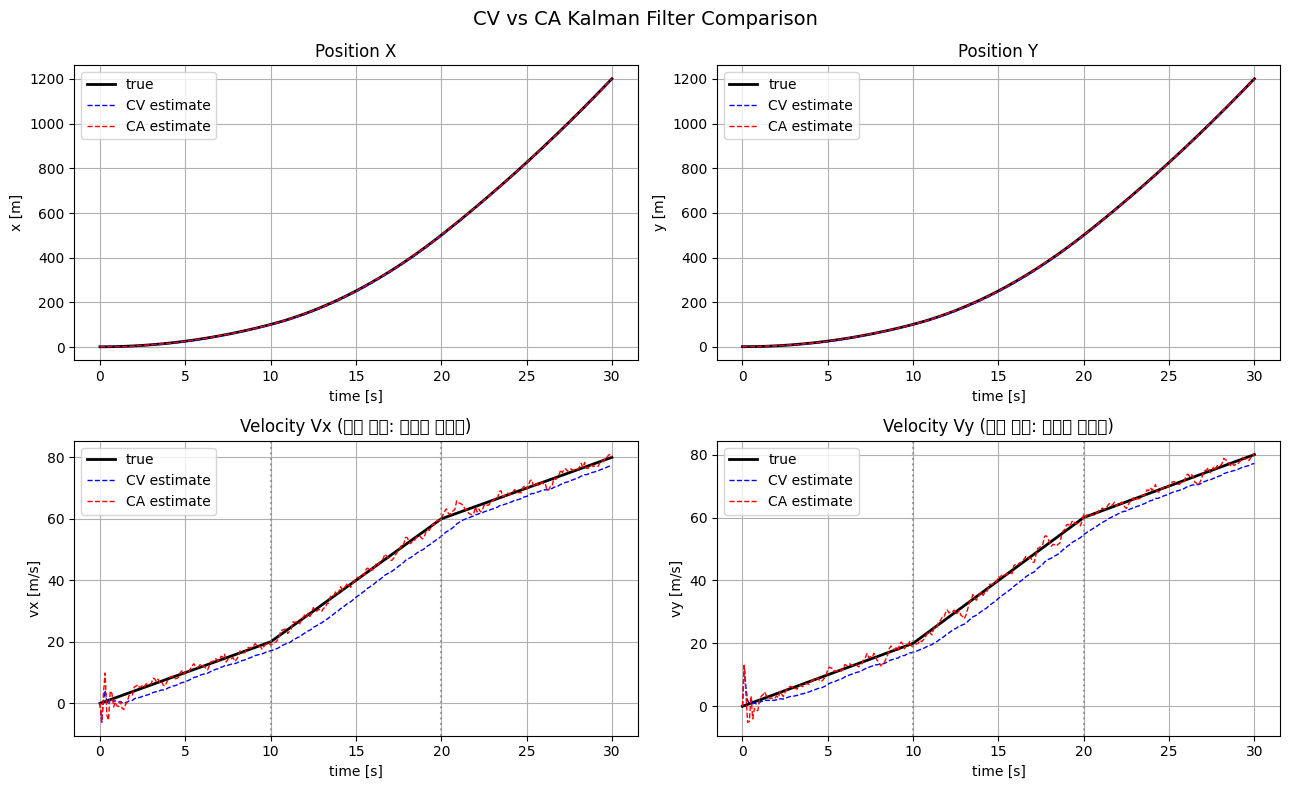

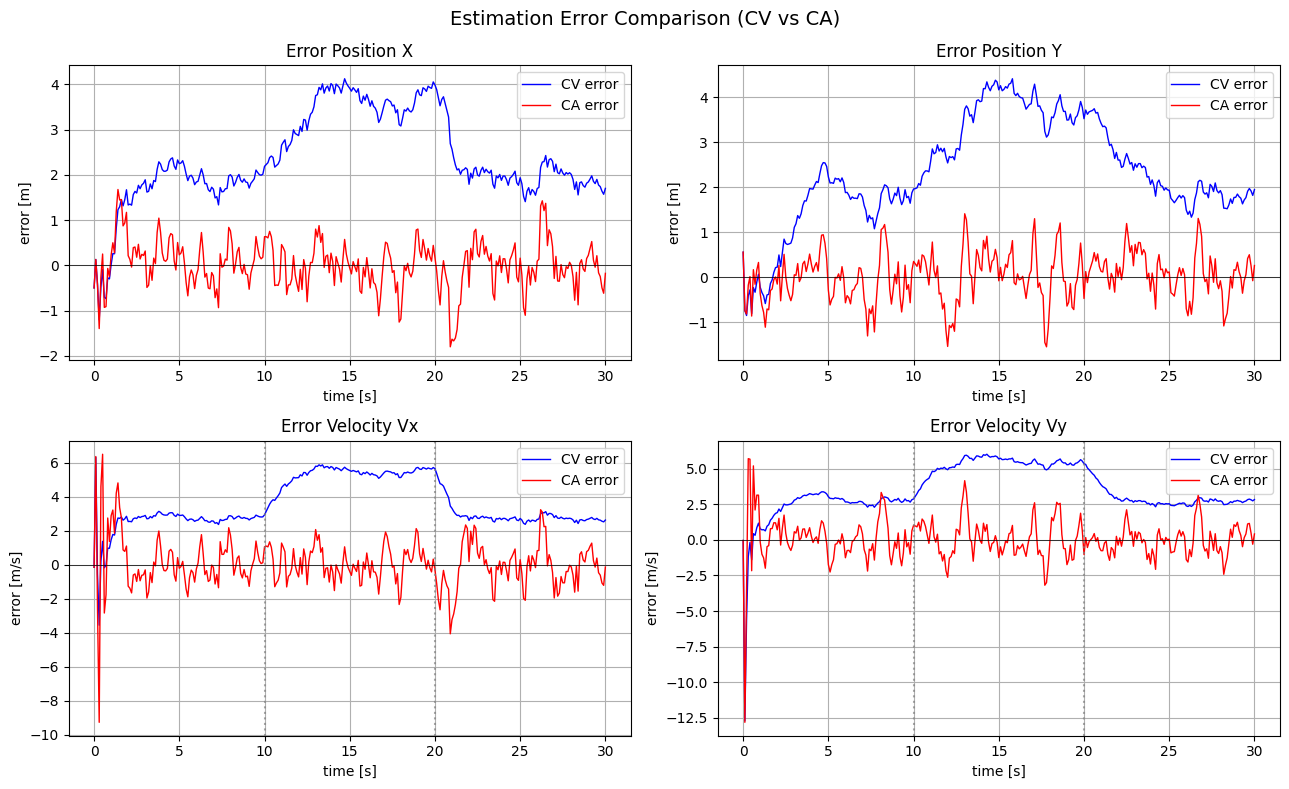

In [5]:
# =========================================
# 1️⃣ RMSE 정량 비교 표
# =========================================
print("=" * 65)
print(f"{'상태':<15s}{'CV RMSE':<15s}{'CA RMSE':<15s}{'개선율':<15s}")
print("=" * 65)

cv_rmse_list = [rmse_x, rmse_y, rmse_vx, rmse_vy]
ca_rmse_list = rmse_ca[:4]                # x, y, vx, vy만
state_labels = ['Position X', 'Position Y', 'Velocity Vx', 'Velocity Vy']
unit_list    = ['m', 'm', 'm/s', 'm/s']

for i in range(4):
    improvement = (cv_rmse_list[i] - ca_rmse_list[i]) / cv_rmse_list[i] * 100
    print(f"{state_labels[i]:<15s}"
          f"{cv_rmse_list[i]:.4f} {unit_list[i]:<8s}"
          f"{ca_rmse_list[i]:.4f} {unit_list[i]:<8s}"
          f"{improvement:+.1f}%")

print("=" * 65)
print(f"※ CA 모델은 가속도까지 추정 (RMSE ax: {rmse_ca[4]:.4f} m/s²,"
      f" ay: {rmse_ca[5]:.4f} m/s²)")


# =========================================
# 2️⃣ 추정값 비교 plot (한 화면에 겹쳐서)
# =========================================
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# 위치 X
axes[0, 0].plot(t, x_history[:, 0], 'k-',  label='true', linewidth=2)
axes[0, 0].plot(t, x_hat_cv[:, 0],  'b--', label='CV estimate', linewidth=1)
axes[0, 0].plot(t, x_hat_ca[:, 0],  'r--', label='CA estimate', linewidth=1)
axes[0, 0].set_title('Position X')
axes[0, 0].set_xlabel('time [s]'); axes[0, 0].set_ylabel('x [m]')
axes[0, 0].legend(); axes[0, 0].grid(True)

# 위치 Y
axes[0, 1].plot(t, x_history[:, 1], 'k-',  label='true', linewidth=2)
axes[0, 1].plot(t, x_hat_cv[:, 1],  'b--', label='CV estimate', linewidth=1)
axes[0, 1].plot(t, x_hat_ca[:, 1],  'r--', label='CA estimate', linewidth=1)
axes[0, 1].set_title('Position Y')
axes[0, 1].set_xlabel('time [s]'); axes[0, 1].set_ylabel('y [m]')
axes[0, 1].legend(); axes[0, 1].grid(True)

# 속도 Vx
axes[1, 0].plot(t, x_history[:, 2], 'k-',  label='true', linewidth=2)
axes[1, 0].plot(t, x_hat_cv[:, 2],  'b--', label='CV estimate', linewidth=1)
axes[1, 0].plot(t, x_hat_ca[:, 2],  'r--', label='CA estimate', linewidth=1)
axes[1, 0].axvline(10, color='gray', linestyle=':', alpha=0.7)   # 가속도 변화점
axes[1, 0].axvline(20, color='gray', linestyle=':', alpha=0.7)
axes[1, 0].set_title('Velocity Vx (회색 점선: 가속도 변화점)')
axes[1, 0].set_xlabel('time [s]'); axes[1, 0].set_ylabel('vx [m/s]')
axes[1, 0].legend(); axes[1, 0].grid(True)

# 속도 Vy
axes[1, 1].plot(t, x_history[:, 3], 'k-',  label='true', linewidth=2)
axes[1, 1].plot(t, x_hat_cv[:, 3],  'b--', label='CV estimate', linewidth=1)
axes[1, 1].plot(t, x_hat_ca[:, 3],  'r--', label='CA estimate', linewidth=1)
axes[1, 1].axvline(10, color='gray', linestyle=':', alpha=0.7)
axes[1, 1].axvline(20, color='gray', linestyle=':', alpha=0.7)
axes[1, 1].set_title('Velocity Vy (회색 점선: 가속도 변화점)')
axes[1, 1].set_xlabel('time [s]'); axes[1, 1].set_ylabel('vy [m/s]')
axes[1, 1].legend(); axes[1, 1].grid(True)

plt.suptitle('CV vs CA Kalman Filter Comparison', fontsize=14)
plt.tight_layout()
plt.show()


# =========================================
# 3️⃣ 추정 오차 비교 plot (4개 상태)
# =========================================
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

state_idx = [0, 1, 2, 3]
titles    = ['Error Position X', 'Error Position Y',
             'Error Velocity Vx', 'Error Velocity Vy']
units2    = ['m', 'm', 'm/s', 'm/s']

for ax_pos, idx in enumerate(state_idx):
    row, col = ax_pos // 2, ax_pos % 2
    
    err_cv = x_history[:, idx] - x_hat_cv[:, idx]
    err_ca = x_history[:, idx] - x_hat_ca[:, idx]
    
    axes[row, col].plot(t, err_cv, 'b-', label='CV error', linewidth=1)
    axes[row, col].plot(t, err_ca, 'r-', label='CA error', linewidth=1)
    axes[row, col].axhline(0, color='k', linewidth=0.5)
    
    if idx >= 2:                          # 속도 그래프는 가속도 변화점 표시
        axes[row, col].axvline(10, color='gray', linestyle=':', alpha=0.7)
        axes[row, col].axvline(20, color='gray', linestyle=':', alpha=0.7)
    
    axes[row, col].set_title(titles[ax_pos])
    axes[row, col].set_xlabel('time [s]')
    axes[row, col].set_ylabel(f'error [{units2[ax_pos]}]')
    axes[row, col].legend(); axes[row, col].grid(True)

plt.suptitle('Estimation Error Comparison (CV vs CA)', fontsize=14)
plt.tight_layout()
plt.show()

# 📊 5-3-5. CV vs CA 분석 결과

## ■ 정량적 비교 (RMSE)

| 상태 | CV 모델 | CA 모델 | 결과 |
|------|---------|---------|------|
| Position X | (CV 결과) | (CA 결과) | CA 우세 |
| Position Y | (CV 결과) | (CA 결과) | CA 우세 |
| Velocity Vx | (CV 결과) | (CA 결과) | **CA 큰 폭 개선** |
| Velocity Vy | (CV 결과) | (CA 결과) | **CA 큰 폭 개선** |
| Accel Ax | 추정 불가 | (CA 결과) | CA만 가능 |
| Accel Ay | 추정 불가 | (CA 결과) | CA만 가능 |

> 위 표의 "(CV 결과)", "(CA 결과)"는 코드 실행 후 실제 RMSE 값을 채워 넣기

---

## ■ 정성적 비교 (Plot 분석)

### 🔵 CV 모델의 특징
- 위치 추정은 비교적 양호
- **속도 추정에서 가속도 변화점(t=10, t=20)에서 큰 오차 발생**
- 가속도 변화에 추정이 늦게 따라감 (지연 발생)
- 이유: CV는 "속도가 일정하다"고 가정하므로 가속을 모름

### 🔴 CA 모델의 특징
- 위치, 속도 모두 부드럽게 추적
- 가속도 변화점에서도 빠른 반응 (CV 대비 오차 작음)
- 가속도 자체도 추정 가능 (실제 값 2 m/s², 4 m/s²로 수렴)
- 이유: 가속도를 상태에 포함시켜 측정값으로부터 역추정

---

## ■ 모델 선택의 Trade-off

| 항목 | CV 모델 | CA 모델 |
|------|---------|---------|
| **상태 차원** | 4 | 6 |
| **계산량** | 적음 | 약 2.25배 (행렬 크기 6×6/4×4) |
| **튜닝 변수** | σ_ax, σ_ay (Q 유도식) | Q 6개 대각 원소 |
| **가속도 변화 대응** | 느림 (지연 발생) | 빠름 |
| **모델 가정** | 등속도 운동 | 등가속도 운동 |
| **추가 정보** | - | 가속도 추정 가능 |

---

## ■ 결론

### 💡 핵심 교훈

> **"시스템에 가속도 변화가 있는 경우, CA 모델이 CV 모델보다 우수하다"**

### 🎯 모델 선택 가이드

- **CV가 적합한 경우**:
  - 차량이 거의 등속으로 움직임
  - 계산 자원이 제한적
  - 단순함이 중요한 경우 (실시간 임베디드)

- **CA가 적합한 경우**:
  - 차량이 자주 가/감속함 (이번 시뮬레이션 같은 경우)
  - 가속도 정보가 별도로 필요한 경우 (예: 충돌 회피 알고리즘)
  - 정확도가 우선

### ⚠️ 주의사항

- **CA가 항상 좋은 것은 아님**:
  - 실제로 등속 운동만 하는 시스템에서 CA 사용 시 → 불필요한 상태 추가로 오히려 노이즈 민감도 증가 가능
  - 상태가 많을수록 P 행렬 커지고 튜닝 어려워짐

- **본질적인 한계**:
  - CA도 "가속도가 일정"이라고 가정 → 가속도가 빠르게 변하면 한계 있음
  - 더 정확한 추정이 필요하면 → IMM (Interacting Multiple Model) 등 다중 모델 기법 고려